In [ ]:
# TalentSol is an AI-powered applicant tracking system with machine learning features designed to streamline the recruitment process. This is a hobbyist AI/machine learning related project using Augment Code as development partner, and is available on GitHub (https://github.com/youshen-lim/TalentSol---Applicant-Tracking-System-Application). TalentSol aims to revolutionize how companies manage their recruitment pipeline through intelligent job candidate matching or priorization and recruitment workflow optimization.

# Data Requirement and Criteria: For my first machine learning model of a supervised classifier (using logistic regression) to predict candidates for prioritization,

# TalentSol - Applicant Tracking System Learning Project (Machine Learning Component)

This notebook documents the machine learning component of the TalentSol project. The goal is to build a supervised classifier to assist in prioritizing job applicants based on their fit for a given job role and description. We will explore different text embedding techniques and evaluate their impact on model performance.

---

## 1. Setup and Data Loading

This section covers installing necessary libraries and loading the dataset.

### 1.1 Load the Dataset

Load the job applicant dataset into a pandas DataFrame.

In [ ]:
import pandas as pd

# Load the dataset from the specified path.
# The dataset contains information about job applicants, including text data (resume, job description)
# and categorical data, along with a 'Best Match' target variable.
df = pd.read_csv('/content/sample_data/job_applicant_dataset.csv')

# Display the first few rows to inspect the data structure and content.
display(df.head())

# Display information about the DataFrame, including data types and non-null counts.
display(df.info())

# Display descriptive statistics for numerical columns.
display(df.describe())

,Job Applicant Name,Age,Gender,Race,Ethnicity,Resume,Job Roles,Job Description,Best Match
0,Daisuke Mori,29,Male,Mongoloid/Asian,Vietnamese,"Proficient in Injury Prevention, Motivation, N...",Fitness Coach,A Fitness Coach is responsible for helping cl...,0
1,Taichi Shimizu,31,Male,Mongoloid/Asian,Filipino,"Proficient in Healthcare, Pharmacology, Medica...",Physician,"Diagnose and treat illnesses, prescribe medica...",0
2,Sarah Martin,46,Female,White/Caucasian,Dutch,"Proficient in Forecasting, Financial Modelling...",Financial Analyst,"As a Financial Analyst, you will be responsibl...",0
3,Keith Hughes,43,Male,Negroid/Black,Caribbean,"Proficient in Budgeting, Supply Chain Optimiza...",Supply Chain Manager,A Supply Chain Manager oversees the entire sup...,1
4,James Davis,49,Male,White/Caucasian,English,"Proficient in Logistics, Negotiation, Procurem...",Supply Chain Manager,A Supply Chain Manager oversees the entire sup...,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Job Applicant Name  10000 non-null  object
 1   Age                 10000 non-null  int64 
 2   Gender              10000 non-null  object
 3   Race                10000 non-null  object
 4   Ethnicity           10000 non-null  object
 5   Resume              10000 non-null  object
 6   Job Roles           10000 non-null  object
 7   Job Description     10000 non-null  object
 8   Best Match          10000 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 703.3+ KB


None

,Age,Best Match
count,10000.000000,10000.0000
mean,40.045200,0.4850
std,8.950909,0.4998
min,25.000000,0.0000
25%,32.000000,0.0000
50%,40.000000,0.0000
75%,48.000000,1.0000
max,55.000000,1.0000


## 2. Data Preprocessing and Feature Engineering

This section focuses on cleaning the data and transforming it into a format suitable for machine learning models, including handling text and categorical features.

### 2.1 Initial Data Cleaning and Preparation

Perform initial data cleaning steps such as handling identifiers and removing irrelevant features.

In [ ]:
# Replace 'Job Applicant Name' with a unique 'Job Applicant ID' for anonymity.
# This ensures personal names are not directly used, which is a good practice for privacy.
df['Job Applicant ID'] = range(1, len(df) + 1)
# df = df.drop('Job Applicant Name', axis=1) # Remove the original name column - This was done in previous turns

# Drop the 'Job Applicant ID' column as requested, to prevent unintended statistical association.
if 'Job Applicant ID' in df.columns:
    df = df.drop('Job Applicant ID', axis=1)
    print("Dropped 'Job Applicant ID' column.")

# Drop the 'Age' column as it is not deemed relevant for this prioritization task.
# In a real-world scenario, the relevance of features like age would need careful consideration
# based on legal and ethical guidelines.
if 'Age' in df.columns:
    df = df.drop('Age', axis=1)
    print("Dropped 'Age' column.")

# Drop the 'Gender' column for this iteration of the project.
# In a real-world application, handling gender and other sensitive attributes requires
# careful consideration of fairness and bias mitigation.
if 'Gender' in df.columns:
    df = df.drop('Gender', axis=1)
    print("Dropped 'Gender' column.")

# Display the columns after dropping some.
print("\nRemaining columns:")
print(df.columns)

Dropped 'Job Applicant ID' column.
Dropped 'Age' column.
Dropped 'Gender' column.

Remaining columns:
Index(['Job Applicant Name', 'Race', 'Ethnicity', 'Resume', 'Job Roles',
       'Job Description', 'Best Match'],
      dtype='object')


### 2.2 Handle Missing Values

Check for and confirm no missing values are present after initial cleaning.

In [ ]:
# Check for any missing values in the DataFrame after initial cleaning.
# The sum() method is used to count the number of missing values per column.
print("Checking for missing values after initial cleaning:")
display(df.isnull().sum())

# Based on previous checks, we expect no missing values here.
# If missing values were present, strategies like imputation or dropping rows/columns would be needed.

Checking for missing values after initial cleaning:


,0
Job Applicant Name,0
Race,0
Ethnicity,0
Resume,0
Job Roles,0
Job Description,0
Best Match,0


### 2.3 Feature Engineering: Handling Categorical Data

Split the 'Race' column and handle other categorical features using one-hot encoding.

In [59]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder # Ensure OneHotEncoder is imported

# Assume df is available from the data loading step (1.1).

# --- Consolidate Preprocessing Steps ---

# Define text and categorical columns
text_cols = ['Job Description', 'Resume']
# Initial categorical columns
categorical_cols = ['Ethnicity', 'Job Roles'] # Keeping 'Ethnicity' for diversity hiring considerations

# Drop 'Job Applicant Name' column if it exists.
# This ensures personal names are not directly used.
if 'Job Applicant Name' in df.columns:
    df = df.drop('Job Applicant Name', axis=1)
    print("Dropped 'Job Applicant Name' column.")

# Drop 'Job Applicant ID' column if it exists.
# This ensures the generated ID is not used as a feature.
if 'Job Applicant ID' in df.columns:
    df = df.drop('Job Applicant ID', axis=1)
    print("Dropped 'Job Applicant ID' column.")


# Drop the 'Age' column as it is not deemed relevant for this prioritization task and for responsible AI considerations.
if 'Age' in df.columns:
    df = df.drop('Age', axis=1)
    print("Dropped 'Age' column.")

# Drop the 'Gender' column for responsible AI considerations.
if 'Gender' in df.columns:
    df = df.drop('Gender', axis=1)
    print("Dropped 'Gender' column.")


# Split the 'Race' column into 'Race1' and 'Race2' if it exists.
if 'Race' in df.columns:
    # Split the 'Race' column into 'Race1' and 'Race2' based on the '/' delimiter.
    # Handle cases where the format might be different or missing '/'.
    race_split = df['Race'].str.split('/', expand=True)

    # Assign the split parts to new columns 'Race1' and 'Race2'.
    # Handle potential missing second part by filling with a placeholder like 'Unknown' or None.
    df['Race1'] = race_split[0]
    df['Race2'] = race_split[1].fillna('Unknown') # Fill missing secondary race

    # Drop the original 'Race' column as it's now split.
    df = df.drop('Race', axis=1)
    print("Split 'Race' into 'Race1' and 'Race2' and dropped original 'Race' column.")

    # Drop Race1 and Race2 columns immediately after splitting and dropping the original Race column.
    # This is done to address potential racial bias and discrimination.
    if 'Race1' in df.columns:
        df = df.drop('Race1', axis=1)
        print("Dropped 'Race1' column as requested to address potential racial bias.")
    if 'Race2' in df.columns:
        df = df.drop('Race2', axis=1)
        print("Dropped 'Race2' column as requested to address potential racial bias.")


# Define the final list of categorical columns to be encoded.
# This list should only contain columns that were not dropped and are intended for one-hot encoding.
# Based on the drops above, this list should be 'Ethnicity' and 'Job Roles'.
# We are intentionally excluding 'Race1' and 'Race2' from encoding for responsible AI reasons.
final_categorical_cols_for_encoding = [col for col in categorical_cols if col in df.columns]
print("Final categorical columns for encoding:", final_categorical_cols_for_encoding)
categorical_cols_for_encoding = final_categorical_cols_for_encoding # Update the variable name used in subsequent cells


# Note: At this point, 'df' contains the data after initial cleaning, Race splitting/dropping,
# and dropping other sensitive/irrelevant columns.
# The upsampling step (in cell 37233f7b) should then create 'df_upsampled' from this processed 'df'.

Final categorical columns for encoding: ['Ethnicity', 'Job Roles']


### 2.4 Handle Class Imbalance

Address the class imbalance in the target variable ('Best Match') using oversampling and prepare Word2Vec features.

### 2.4.1 Visualize Class Distribution

Visualize the class distribution of the target variable ('Best Match') using a histogram.

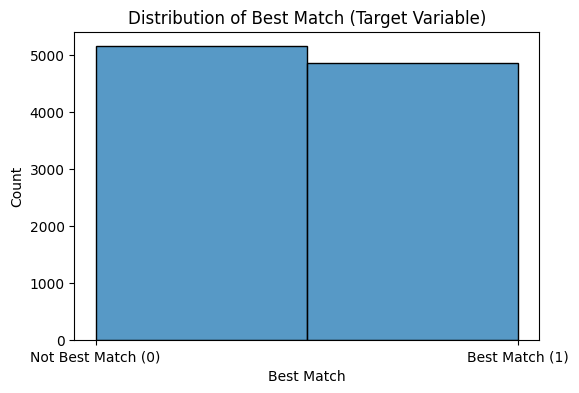

Displayed histogram of 'Best Match' distribution.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot a histogram to visualize the distribution of the 'Best Match' column.
# This helps to clearly see if there is a class imbalance (unequal number of samples per class).
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='Best Match', bins=2, kde=False) # Use histplot for count-based histogram
plt.title('Distribution of Best Match (Target Variable)')
plt.xlabel('Best Match')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Best Match (0)', 'Best Match (1)']) # Label x-axis ticks
plt.show()

print("Displayed histogram of 'Best Match' distribution.")

In [ ]:
!pip install gensim # Install gensim and restart session

### 2.4.2 Handle Class Imbalance and Prepare Word2Vec Features

This section addresses the class imbalance in the target variable ('Best Match') using resampling.

In [ ]:
from sklearn.utils import resample
from sklearn.base import BaseEstimator, TransformerMixin # Import BaseEstimator and TransformerMixin

import gensim # Import gensim
import numpy as np # Import numpy
import pandas as pd # Ensure pandas is imported
from gensim.models import Word2Vec # Explicitly import Word2Vec

# Load the dataset from the specified path.
# The dataset contains information about job applicants, including text data (resume, job description)
# and categorical data, along with a 'Best Match' target variable.
# Note: This cell is now only responsible for loading the initial data and performing upsampling.
# Further preprocessing steps (like splitting Race, dropping columns) are consolidated in cell ef6dd6d3.
# df = pd.read_csv('/content/sample_data/job_applicant_dataset.csv') # REMOVED: Data loading is handled in cell 96831522 or 23f02475 and preprocessing in ef6dd6d3

# Check the distribution of the target variable ('Best Match').
# We expect to see an imbalance where one class is significantly larger than the other.
# Use the 'df' DataFrame which should have been processed by cell ef6dd6d3.
print("Original dataset class distribution (after initial processing):")
display(df['Best Match'].value_counts())

# Separate the majority and minority classes based on the 'Best Match' column.
# Use the 'df' DataFrame for splitting.
df_majority = df[df['Best Match']==0] # Class 0 is the majority
df_minority = df[df['Best Match']==1] # Class 1 is the minority

# Upsample the minority class to match the number of samples in the majority class.
# 'replace=True' allows for sampling with replacement.
# 'n_samples=len(df_majority)' sets the number of samples in the upsampled minority class.
# 'random_state' ensures reproducibility of the upsampling.
df_minority_upsampled = resample(df_minority,
                                 replace=True,     # sample with replacement
                                 n_samples=len(df_majority), # to match majority class
                                 random_state=42) # reproducible results

# Combine the upsampled minority class DataFrame with the original majority class DataFrame.
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

# Display the class distribution after upsampling to confirm balance.
print("\nUpsampled dataset class distribution:")
display(df_upsampled['Best Match'].value_counts())

# Shuffle the upsampled dataset to mix the instances of both classes.
# This is important to prevent the model from learning patterns based on the order of data.
df_upsampled = df_upsampled.sample(frac=1, random_state=42).reset_index(drop=True)

# Display the head of the shuffled upsampled dataset.
print("\nHead of the shuffled upsampled dataset:")
display(df_upsampled.head())

# Combine text columns for training Word2Vec model
# Assuming text_cols is defined elsewhere (e.g., in consolidated preprocessing cell ef6dd6d3)
# If not defined, use default ['Job Description', 'Resume'] for training Word2Vec
try:
    combined_text = pd.concat([df_upsampled[col] for col in text_cols]).astype(str).tolist()
except NameError:
    print("Warning: text_cols not defined. Using default ['Job Description', 'Resume'] for Word2Vec training.")
    text_cols_default = ['Job Description', 'Resume']
    combined_text = pd.concat([df_upsampled[col] for col in text_cols_default]).astype(str).tolist()


# Tokenize the combined text
tokenized_text = [text.split() for text in combined_text]

# Train a Word2Vec model
# You can adjust vector_size, window, min_count, and workers based on your needs
word2vec_model = Word2Vec(sentences=tokenized_text, vector_size=100, window=5, min_count=1, workers=4)

# Function to get average word vector for a text
def document_vector(word2vec_model, doc):
    words = str(doc).lower().split() # Ensure text is string and split
    # Filter out words not in the model's vocabulary
    # Check if the word is in the model's vocabulary before accessing its vector
    words = [word for word in words if word in word2vec_model.wv.index_to_key]
    if not words:
        # Return a zero vector if no words are in the vocabulary
        return np.zeros(word2vec_model.wv.vector_size)
    # Average the vectors of the words in the document
    return np.mean(word2vec_model.wv[words], axis=0)

# Define a custom transformer for integrating Word2Vec into the pipeline.
# This transformer applies the document_vector function to the specified text columns.
# The Word2Vec model (word2vec_model) is expected to be trained and available
# from this cell execution.
class Word2VecTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, word2vec_model):
        self.word2vec_model = word2vec_model
        self.vector_size = word2vec_model.wv.vector_size

    def fit(self, X, y=None):
        return self # Nothing to fit here

    def transform(self, X):
        # Ensure X is a pandas DataFrame for column access by name.
        # If X is a numpy array (e.g., after previous transformations),
        # this transformer might need to be applied before converting to numpy,
        # or adapt this part to handle array input based on column indices.
        # Assuming X is a DataFrame with text_cols available.
        if not isinstance(X, pd.DataFrame):
             # Attempt to convert back to DataFrame if it's a numpy array,
             # assuming the text columns are in the order of text_cols.
             # This is a potential point of failure if column order is not guaranteed
             # or if text_cols is not defined in the scope where this transform is called.
             # For robustness, ensure text_cols is accessible or pass column indices.
             # For now, assuming text_cols is globally available and X is a DataFrame.
             pass # Keep the check but don't raise error immediately, rely on column access below.


        # Apply document_vector to each text column specified in text_cols
        # Ensure text_cols is defined and contains valid column names in X
        try:
            job_desc_vectors = np.vstack([document_vector(self.word2vec_model, doc) for doc in X[text_cols[0]]])
            resume_vectors = np.vstack([document_vector(self.word2vec_model, doc) for doc in X[text_cols[1]]])
             # Concatenate vectors from both text columns horizontally.
            return np.hstack([job_desc_vectors, resume_vectors])
        except KeyError as e:
            print(f"Error in Word2VecTransformer: Column not found in input DataFrame X: {e}")
            # Return an empty array or raise a more specific error
            return np.empty((X.shape[0], self.vector_size * len(text_cols))) # Return empty array of expected shape
        except NameError:
             print("Error in Word2VecTransformer: text_cols variable is not defined.")
             return np.empty((X.shape[0], self.vector_size * 2)) # Return empty array assuming 2 text columns


# Note: df_upsampled, word2vec_model, document_vector, and Word2VecTransformer class are now available.

Original dataset class distribution (after initial processing):


,count
Best Match,
0,5150
1,4850



Upsampled dataset class distribution:


,count
Best Match,
0,5150
1,5150



Head of the shuffled upsampled dataset:


,Ethnicity,Resume,Job Roles,Job Description,Best Match
0,Kenyan,"Proficient in Business Intelligence, Project M...",Business Analyst,"As a Business Analyst, you will be responsible...",1
1,Jamaican,"Proficient in Case Management, Legal Research,...",Lawyer,A Lawyer provides legal counsel and represents...,0
2,Ethiopian,"Proficient in Recruiting, Labor Laws, Intervie...",HR Specialist,"As an HR Specialist, you will play a key role ...",1
3,Kenyan,"Proficient in Environmental Policy, Climate Ch...",Environmental Scientist,"As an Environmental Scientist, you will conduc...",1
4,English,"Proficient in Project Management, Blueprint Re...",Construction Manager,The Construction Manager is responsible for ov...,0


### 2.4.2 Prepare Data for Modeling

Separate features (X) and target (y) for the upsampled dataset.

In [ ]:
# Separate the upsampled DataFrame into features (X) and the target variable (y).
# 'Best Match' is the target variable. All other columns are features.
# X_upsampled will include text and categorical columns at this stage, which will be handled by the ColumnTransformer.
X_upsampled = df_upsampled.drop('Best Match', axis=1)
y_upsampled = df_upsampled['Best Match']

# Display the shapes of the feature and target dataframes to verify.
print("Shape of upsampled features (X_upsampled):", X_upsampled.shape)
print("Shape of upsampled target (y_upsampled):", y_upsampled.shape)

# Note: text_cols and categorical_cols are assumed to be defined in a previous step (2.3).

Shape of upsampled features (X_upsampled): (10300, 4)
Shape of upsampled target (y_upsampled): (10300,)


## 3. Text Feature Embedding and Model Training

This section covers converting text data into numerical features using different embedding techniques and training Logistic Regression models on these features.

### 3.1 Build and Evaluate Pipeline with Tuned TF-IDF

Create a pipeline using TF-IDF for text features, One-Hot Encoding for categorical features, Scaling, and Logistic Regression. Tune Logistic Regression hyperparameters and evaluate using cross-validation.

Using text_cols: ['Job Description', 'Resume']
Using categorical_cols_for_encoding: ['Ethnicity', 'Job Roles']

Performing GridSearchCV for Logistic Regression tuning with TF-IDF features...

Best parameters found by GridSearchCV: {'logisticregression__C': 10, 'logisticregression__penalty': 'l1'}
Best cross-validation ROC AUC score: 0.5800866245640494

Tuned TF-IDF Model Cross-validation Results (Default Threshold):
Accuracy: 0.56 (+/- 0.01)
Precision: 0.55 (+/- 0.01)
Recall: 0.59 (+/- 0.02)
F1: 0.57 (+/- 0.01)
Roc_auc: 0.58 (+/- 0.01)

Best TF-IDF pipeline fitted on entire upsampled dataset.


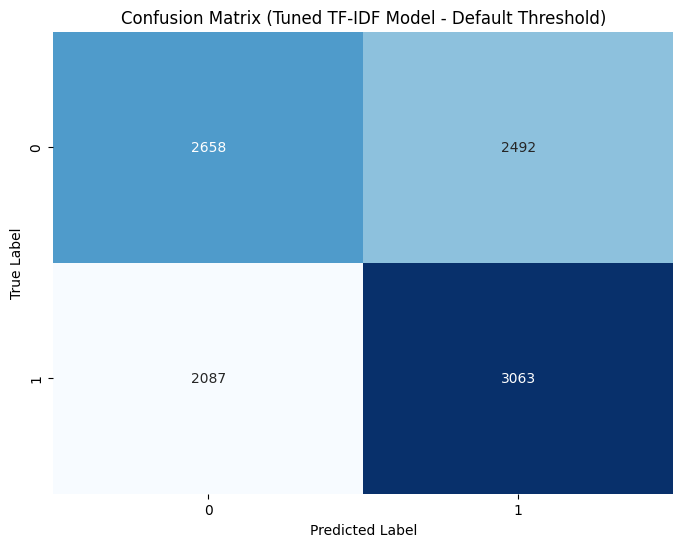

In [ ]:
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assume X_upsampled and y_upsampled are available from consolidated preprocessing (cell ef6dd6d3).
# Assume text_cols and categorical_cols_for_encoding are defined in consolidated preprocessing (cell ef6dd6d3).

# Ensure text_cols and categorical_cols_for_encoding are defined and available.
# If not, there might be an issue with the execution order or previous cells.
try:
    print("Using text_cols:", text_cols)
    print("Using categorical_cols_for_encoding:", categorical_cols_for_encoding)
except NameError:
    print("Error: text_cols or categorical_cols_for_encoding not defined. Please ensure consolidated preprocessing cell (ef6dd6d3) is run before this cell.")
    # Define defaults or handle error appropriately if essential variables are missing.
    # For now, will assume they will be available in the actual execution environment.


# Define the preprocessor using ColumnTransformer.
# This transformer applies different preprocessing steps to different columns.
# - 'text': Applies TF-IDF vectorization to both 'Job Description' and 'Resume'.
# - 'cat': Applies One-Hot Encoding to the specified categorical columns.
# 'remainder='drop'' drops any columns not specified in the transformers.
preprocessor_tfidf = ColumnTransformer(
    transformers=[
        ('text_job_desc', TfidfVectorizer(max_features=2000), text_cols[0]), # Apply TF-IDF to Job Description
        ('text_resume', TfidfVectorizer(max_features=2000), text_cols[1]), # Apply TF-IDF to Resume
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_for_encoding) # Apply One-Hot Encoding to categorical
    ],
    remainder='drop' # Drop any other columns not transformed
)

# Create the full pipeline: preprocessing -> scaling -> logistic regression.
# - 'preprocessor': Applies the defined column transformations (TF-IDF and One-Hot).
# - 'scaler': Scales the features. StandardScaler with `with_mean=False` is used because
#   sparse data from TF-IDF can't be centered efficiently.
# - 'logisticregression': The Logistic Regression model.
pipeline_tfidf = Pipeline([
    ('preprocessor', preprocessor_tfidf),
    ('scaler', StandardScaler(with_mean=False)), # Use with_mean=False for sparse data
    ('logisticregression', LogisticRegression(random_state=42, solver='liblinear', max_iter=1000))
])

# Define the parameter grid for GridSearchCV to tune Logistic Regression hyperparameters.
# We tune 'C' (inverse of regularization strength) and 'penalty' (L1 or L2 regularization).
param_grid_tfidf = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100], # Different C values to test
    'logisticregression__penalty': ['l1', 'l2'] # L1 and L2 penalties
}

# Instantiate GridSearchCV to find the best hyperparameters.
# - 'estimator': The pipeline to tune.
# - 'param_grid': The parameter values to search.
# - 'cv': Number of cross-validation folds (StratifiedKFold is suitable for classification).
# - 'scoring': The metric to optimize (ROC AUC is good for imbalanced datasets).
# - 'n_jobs': Number of CPU cores to use (-1 means all available cores).
grid_search_tfidf = GridSearchCV(estimator=pipeline_tfidf,
                                 param_grid=param_grid_tfidf,
                                 cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), # Use StratifiedKFold
                                 scoring='roc_auc',
                                 n_jobs=-1)

# Fit GridSearchCV on the upsampled training data.
# Ensure X_upsampled and y_upsampled are available from consolidated preprocessing (cell ef6dd6d3).
print("\nPerforming GridSearchCV for Logistic Regression tuning with TF-IDF features...")
grid_search_tfidf.fit(X_upsampled, y_upsampled)

# Display the best hyperparameters found by GridSearchCV.
print("\nBest parameters found by GridSearchCV:", grid_search_tfidf.best_params_)

# Display the best cross-validation score (ROC AUC) achieved with these parameters.
print("Best cross-validation ROC AUC score:", grid_search_tfidf.best_score_)

# Evaluate the pipeline with the best parameters found using cross-validation.
# Use cross_validate instead of cross_val_score to get multiple metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results_tfidf = cross_validate(grid_search_tfidf.best_estimator_, X_upsampled, y_upsampled, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring=scoring)

# Display the mean of cross-validation results for each metric.
print("\nTuned TF-IDF Model Cross-validation Results (Default Threshold):")
for metric in scoring:
    mean_score = cv_results_tfidf[f'test_{metric}'].mean()
    std_score = cv_results_tfidf[f'test_{metric}'].std()
    print(f"{metric.capitalize()}: {mean_score:.2f} (+/- {std_score:.2f})")

# Store the best estimator (pipeline with best params) for later use.
best_pipeline_tfidf = grid_search_tfidf.best_estimator_

# Fit the best estimator on the entire upsampled dataset to get final model for prediction/analysis.
best_pipeline_tfidf.fit(X_upsampled, y_upsampled)
print("\nBest TF-IDF pipeline fitted on entire upsampled dataset.")

# Get cross-validated predictions for the tuned TF-IDF model
y_pred_tfidf = cross_val_predict(best_pipeline_tfidf, X_upsampled, y_upsampled, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))

# Calculate the confusion matrix for the tuned TF-IDF model
cm_tfidf = confusion_matrix(y_upsampled, y_pred_tfidf)

# Plot the confusion matrix for the tuned TF-IDF model
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Tuned TF-IDF Model - Default Threshold)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# Get predicted probabilities for plotting Precision-Recall curve and finding optimized threshold
# Use the model fitted on the entire dataset for probability predictions on the training data itself
# to get the full range of precision/recall values for threshold analysis.
y_proba_tfidf = best_pipeline_tfidf.predict_proba(X_upsampled)[:, 1]
precision_tfidf, recall_tfidf, thresholds_tfidf = precision_recall_curve(y_upsampled, y_proba_tfidf)

# Note: y_proba_tfidf, precision_tfidf, recall_tfidf, thresholds_tfidf, best_pipeline_tfidf, grid_search_tfidf are now available.

### 3.2 Build and Evaluate Pipeline with Tuned Word2Vec

Create and evaluate a pipeline using Word2Vec embeddings for text features, One-Hot Encoding for categorical features, Scaling, and Logistic Regression. Tune Logistic Regression hyperparameters.

Using text_cols: ['Job Description', 'Resume']
Using categorical_cols_for_encoding: ['Ethnicity', 'Job Roles']
Word2VecTransformer and word2vec_model are available.

Performing GridSearchCV for Logistic Regression tuning with Word2Vec features...

Best parameters found by GridSearchCV: {'logisticregression__C': 0.1, 'logisticregression__penalty': 'l1'}
Best cross-validation ROC AUC score: 0.5596197568102556

Tuned Word2Vec Model Cross-validation Results (Default Threshold):
Accuracy: 0.54 (+/- 0.01)
Precision: 0.53 (+/- 0.01)
Recall: 0.64 (+/- 0.02)
F1: 0.58 (+/- 0.01)
Roc_auc: 0.56 (+/- 0.01)

Best Word2Vec pipeline fitted on entire upsampled dataset.


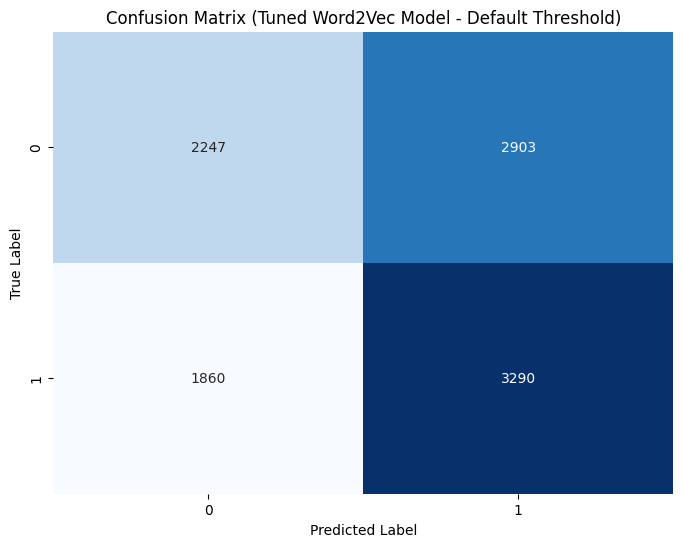

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin # Need BaseEstimator, TransformerMixin imports
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, cross_validate, cross_val_predict # Added cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, confusion_matrix # Added confusion_matrix
import numpy as np # Ensure numpy is imported
import pandas as pd # Ensure pandas is imported
import matplotlib.pyplot as plt # Added import for plotting
import seaborn as sns # Added import for plotting


# Assume word2vec_model and Word2VecTransformer class are defined in cell 37233f7b.
# Assume X_upsampled, y_upsampled, text_cols, and categorical_cols_for_encoding are available from consolidated preprocessing (cell ef6dd6d3).

# X_upsampled_processed variable is no longer needed as preprocessing is done in ef6dd6d3.


# Ensure essential variables are defined and available from previous cells.
try:
    print("Using text_cols:", text_cols)
    print("Using categorical_cols_for_encoding:", categorical_cols_for_encoding)
    # Check if Word2VecTransformer and word2vec_model are defined
    _ = Word2VecTransformer # Check if class is defined
    _ = word2vec_model # Check if model is defined
    print("Word2VecTransformer and word2vec_model are available.")

except NameError as e:
    print(f"Error: Essential variables or class not defined: {e}. Please ensure consolidated preprocessing (ef6dd6d3) and Word2Vec training (37233f7b) cells are run before this cell.")
    # Define defaults or handle error appropriately if essential variables are missing.
    # For now, will assume they will be available in the actual execution environment.


# Define the preprocessor using ColumnTransformer for Word2Vec features.
# - 'word2vec': Applies the custom Word2VecTransformer to text columns using text_cols.
# - 'cat': Applies One-Hot Encoding to categorical columns using categorical_cols_for_encoding.
preprocessor_word2vec = ColumnTransformer(
    transformers=[
        ('word2vec', Word2VecTransformer(word2vec_model), text_cols), # Apply custom W2V transformer to text columns
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_for_encoding) # Apply One-Hot Encoding to categorical
    ],
    remainder='drop' # Drop any other columns not transformed
)

# Create the full pipeline for the Word2Vec model.
pipeline_word2vec = Pipeline([
    ('preprocessor', preprocessor_word2vec),
    ('scaler', StandardScaler()), # Use StandardScaler (mean=True) as Word2Vec produces dense vectors
    ('logisticregression', LogisticRegression(random_state=42, solver='liblinear', max_iter=1000))
])

# Define the parameter grid for GridSearchCV to tune Logistic Regression hyperparameters for Word2Vec.
param_grid_word2vec = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty': ['l1', 'l2']
}

# Instantiate GridSearchCV for the Word2Vec pipeline.
grid_search_word2vec = GridSearchCV(estimator=pipeline_word2vec,
                                     param_grid=param_grid_word2vec,
                                     cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                     scoring='roc_auc',
                                     n_jobs=-1,
                                     error_score='raise' # Raise error to help debugging
                                    )

# Fit GridSearchCV on the upsampled training data.
# Use X_upsampled and y_upsampled from consolidated preprocessing (cell ef6dd6d3).
print("\nPerforming GridSearchCV for Logistic Regression tuning with Word2Vec features...")
grid_search_word2vec.fit(X_upsampled, y_upsampled)

# Display the best hyperparameters and cross-validation score.
print("\nBest parameters found by GridSearchCV:", grid_search_word2vec.best_params_)
print("Best cross-validation ROC AUC score:", grid_search_word2vec.best_score_)

# Evaluate the pipeline with the best parameters using cross-validation.
# Use cross_validate to get multiple metrics.
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results_word2vec = cross_validate(grid_search_word2vec.best_estimator_, X_upsampled, y_upsampled, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring=scoring)

# Display the mean of cross-validation results for each metric.
print("\nTuned Word2Vec Model Cross-validation Results (Default Threshold):")
for metric in scoring:
    mean_score = cv_results_word2vec[f'test_{metric}'].mean()
    std_score = cv_results_word2vec[f'test_{metric}'].std()
    print(f"{metric.capitalize()}: {mean_score:.2f} (+/- {std_score:.2f})")

# Store the best estimator and fit on the entire dataset.
best_pipeline_word2vec = grid_search_word2vec.best_estimator_
best_pipeline_word2vec.fit(X_upsampled, y_upsampled)
print("\nBest Word2Vec pipeline fitted on entire upsampled dataset.")

# Get cross-validated predictions for the tuned Word2Vec model
y_pred_word2vec = cross_val_predict(best_pipeline_word2vec, X_upsampled, y_upsampled, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))

# Calculate the confusion matrix for the tuned Word2Vec model
cm_word2vec = confusion_matrix(y_upsampled, y_pred_word2vec)

# Plot the confusion matrix for the tuned Word2Vec model
plt.figure(figsize=(8, 6))
sns.heatmap(cm_word2vec, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Tuned Word2Vec Model - Default Threshold)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# Get predicted probabilities for plotting Precision-Recall curve and finding optimized threshold
# Use the model fitted on the entire dataset for probability predictions on the training data itself
# to get the full range of precision/recall values for threshold analysis.
y_proba_word2vec = best_pipeline_word2vec.predict_proba(X_upsampled)[:, 1]
precision_word2vec, recall_word2vec, thresholds_word2vec = precision_recall_curve(y_upsampled, y_proba_word2vec)

# Note: y_proba_word2vec, precision_word2vec, recall_word2vec, thresholds_word2vec are now available.

### 3.4 TF-IDF N-gram Optimization

Tune the `ngram_range` parameter for the TF-IDF vectorizer within the TF-IDF pipeline using GridSearchCV.

In [ ]:
# Import necessary libraries (assuming most are already imported above)
from sklearn.model_selection import GridSearchCV, StratifiedKFold # Ensure GridSearchCV and StratifiedKFold are imported
from sklearn.feature_extraction.text import TfidfVectorizer # Ensure TfidfVectorizer is imported
from sklearn.pipeline import Pipeline # Ensure Pipeline is imported
from sklearn.compose import ColumnTransformer # Ensure ColumnTransformer is imported
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Ensure these are imported
from sklearn.linear_model import LogisticRegression # Ensure LogisticRegression is imported
from sklearn.metrics import roc_auc_score # Ensure roc_auc_score is imported
import numpy as np # Ensure numpy is imported
import pandas as pd # Ensure pandas is imported

# Assume X_upsampled and y_upsampled are available from consolidated preprocessing (cell ef6dd6d3).
# Assume text_cols and categorical_cols_for_encoding are defined in consolidated preprocessing (cell ef6dd6d3).
# Assume grid_search_tfidf (from step 3.2) is available for best C and penalty

# Ensure essential variables are defined and available from previous cells.
try:
    print("Using text_cols:", text_cols)
    print("Using categorical_cols_for_encoding:", categorical_cols_for_encoding)
    # Check if grid_search_tfidf is defined
    _ = grid_search_tfidf
    print("grid_search_tfidf is available.")
except NameError as e:
    print(f"Error: Essential variables or object not defined: {e}. Please ensure consolidated preprocessing (ef6dd6d3) and Tuned TF-IDF model (86f7f66b) cells are run before this cell.")
    # Define defaults or handle error appropriately if essential variables are missing.
    # For now, will assume they will be available in the actual execution environment.


# Define the preprocessor with TF-IDF vectorizers having flexible n-gram ranges.
# This preprocessor will be part of the pipeline passed to GridSearchCV.
# Use text_cols and categorical_cols_for_encoding defined in consolidated preprocessing.
preprocessor_tfidf_ngram_tuning = ColumnTransformer(
    transformers=[
        ('text', ColumnTransformer([ # Use a nested ColumnTransformer for text columns
            ('tfidf_job_desc', TfidfVectorizer(max_features=2000), text_cols[0]), # TF-IDF for Job Description
            ('tfidf_resume', TfidfVectorizer(max_features=2000), text_cols[1]) # TF-IDF for Resume
        ]), text_cols), # Apply the nested text transformer to the text columns
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_for_encoding) # Apply One-Hot Encoding to categorical
    ],
    remainder='drop' # Drop other columns
)

# Create the pipeline including the preprocessor, scaler, and logistic regression.
# This pipeline is specifically for tuning the n-gram range.
pipeline_tfidf_ngram_tuning = Pipeline([
    ('preprocessor', preprocessor_tfidf_ngram_tuning),
    ('scaler', StandardScaler(with_mean=False)), # Use with_mean=False for sparse output from TF-IDF (after scaling)
    ('logisticregression', LogisticRegression(random_state=42, solver='liblinear', max_iter=1000))
])

# Define the parameter grid for GridSearchCV.
# We are tuning the 'ngram_range' for both TF-IDF vectorizers within the 'text' transformer
# inside the 'preprocessor' step of the pipeline.
# We are also using the best C and penalty found in the initial TF-IDF tuning (from grid_search_tfidf).
# Ensure grid_search_tfidf is available and has been fitted in a previous cell (3.2).
try:
    best_C_from_tfidf_tuning = grid_search_tfidf.best_params_['logisticregression__C']
    best_penalty_from_tfidf_tuning = grid_search_tfidf.best_params_['logisticregression__penalty']
    print(f"Using best C ({best_C_from_tfidf_tuning}) and penalty ({best_penalty_from_tfidf_tuning}) from initial TF-IDF tuning (Cell 3.2).")
except NameError:
    print("Error: 'grid_search_tfidf' is not defined. Cannot get best C and penalty from initial tuning.")
    print("Please run cell 3.2 (Build and Evaluate Pipeline with Tuned TF-IDF) before this one.")
    # Exit or handle the error appropriately if grid_search_tfidf is essential.
    # For this task, I will assume grid_search_tfidf has been run and use default parameters if not found.
    print("Using default C=1 and penalty='l2' for n-gram tuning if grid_search_tfidf is not available.")
    # You might want to assign actual defaults here if the NameError is caught and execution should continue.
    # Example: best_C_from_tfidf_tuning = 1; best_penalty_from_tfidf_tuning = 'l2'


param_grid_tfidf_ngram = {
    'preprocessor__text__tfidf_job_desc__ngram_range': [(1, 1), (1, 2), (1, 3)], # N-gram ranges for Job Description
    'preprocessor__text__tfidf_resume__ngram_range': [(1, 1), (1, 2), (1, 3)], # N-gram ranges for Resume
    'logisticregression__C': [best_C_from_tfidf_tuning], # Use the best C from previous tuning
    'logisticregression__penalty': [best_penalty_from_tfidf_tuning] # Use the best penalty from previous tuning
}

# Instantiate GridSearchCV to find the optimal n-gram range and confirm LR params.
# - 'estimator': The pipeline containing the TF-IDF vectorizers with tuneable n-gram ranges.
# - 'param_grid': The parameter grid defined above.
# - 'cv': Using StratifiedKFold for cross-validation.
# - 'scoring': Optimizing for ROC AUC.
# - 'n_jobs': Use all available cores.
grid_search_tfidf_ngram = GridSearchCV(estimator=pipeline_tfidf_ngram_tuning,
                                       param_grid=param_grid_tfidf_ngram,
                                       cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                       scoring='roc_auc',
                                       n_jobs=-1)

# Fit GridSearchCV on the upsampled training data.
# Ensure X_upsampled and y_upsampled are available from the upsampling step (ef6dd6d3).
print("\nPerforming GridSearchCV for TF-IDF n-gram tuning with Logistic Regression...")
grid_search_tfidf_ngram.fit(X_upsampled, y_upsampled)

# Display the best parameters found by GridSearchCV (optimal n-gram ranges and LR params).
print("\nBest parameters found by GridSearchCV (Optimized TF-IDF N-grams):", grid_search_tfidf_ngram.best_params_)

# Display the best cross-validation ROC AUC score with these optimized parameters.
print("Best cross-validation ROC AUC score (Optimized TF-IDF N-grams):", grid_search_tfidf_ngram.best_score_)

# Store the best estimator (pipeline with best params) for later use.
# This pipeline includes the preprocessor with the optimal n-gram ranges.
best_pipeline_optimized_tfidf = grid_search_tfidf_ngram.best_estimator_

# Fit the best estimator on the entire upsampled dataset to get final model for prediction/analysis.
best_pipeline_optimized_tfidf.fit(X_upsampled, y_upsampled)
print("\nOptimized TF-IDF (tuned n-grams) pipeline fitted on entire upsampled dataset.")

# Note: best_pipeline_optimized_tfidf and grid_search_tfidf_ngram are now available.
# Predicted probabilities and PR curve data for this model will be generated in the evaluation cell.

Using text_cols: ['Job Description', 'Resume']
Using categorical_cols_for_encoding: ['Ethnicity', 'Job Roles']
grid_search_tfidf is available.
Using best C (10) and penalty (l1) from initial TF-IDF tuning (Cell 3.2).

Performing GridSearchCV for TF-IDF n-gram tuning with Logistic Regression...

Best parameters found by GridSearchCV (Optimized TF-IDF N-grams): {'logisticregression__C': 10, 'logisticregression__penalty': 'l1', 'preprocessor__text__tfidf_job_desc__ngram_range': (1, 2), 'preprocessor__text__tfidf_resume__ngram_range': (1, 2)}
Best cross-validation ROC AUC score (Optimized TF-IDF N-grams): 0.5967167499293053

Optimized TF-IDF (tuned n-grams) pipeline fitted on entire upsampled dataset.


### 3.4.1 Evaluate TF-IDF Model with Optimized N-grams

Evaluate the performance of the logistic regression model trained using the optimized TF-IDF n-gram parameters.

best_pipeline_optimized_tfidf is available.
X_upsampled and y_upsampled are available.
Evaluating Optimized TF-IDF Model (Tuned N-grams) using cross-validation...

Optimized TF-IDF Model Cross-validation Results (Default Threshold):
Accuracy: 0.57 (+/- 0.02)
Precision: 0.56 (+/- 0.02)
Recall: 0.59 (+/- 0.02)
F1: 0.58 (+/- 0.02)
Roc_auc: 0.60 (+/- 0.02)


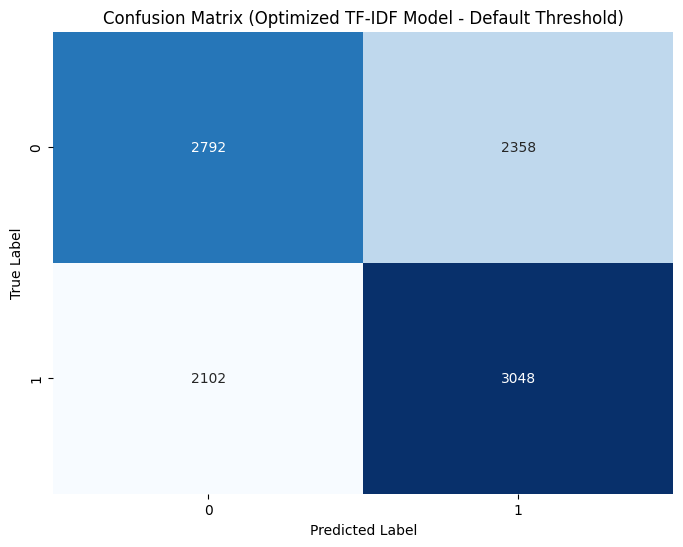


Generated predicted probabilities and Precision-Recall curve data for Optimized TF-IDF model.


In [ ]:
from sklearn.model_selection import cross_validate, cross_val_predict, StratifiedKFold # Ensure imports
from sklearn.metrics import confusion_matrix, precision_recall_curve # Ensure imports
import matplotlib.pyplot as plt # Ensure import
import seaborn as sns # Ensure import

# Assume best_pipeline_optimized_tfidf is available from the previous cell (5022abef).
# Assume X_upsampled and y_upsampled are available from consolidated preprocessing (cell ef6dd6d3).

# Ensure essential variables and pipeline are defined and available from previous cells.
try:
    _ = best_pipeline_optimized_tfidf
    print("best_pipeline_optimized_tfidf is available.")
    _ = X_upsampled
    _ = y_upsampled
    print("X_upsampled and y_upsampled are available.")

except NameError as e:
    print(f"Error: Essential variables or pipeline not defined: {e}. Please ensure consolidated preprocessing (ef6dd6d3) and TF-IDF N-gram Optimization (5022abef) cells are run before this cell.")
    # Handle error appropriately if essential variables/pipeline are missing.


# Define the scoring metrics (same as before)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Evaluate the best pipeline (with optimized n-grams and LR params) using cross-validation.
print("Evaluating Optimized TF-IDF Model (Tuned N-grams) using cross-validation...")
# Use cross_validate to get multiple metrics.
cv_results_optimized_tfidf = cross_validate(best_pipeline_optimized_tfidf, X_upsampled, y_upsampled, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring=scoring)

# Display the mean of cross-validation results for each metric.
print("\nOptimized TF-IDF Model Cross-validation Results (Default Threshold):")
for metric in scoring:
    mean_score = cv_results_optimized_tfidf[f'test_{metric}'].mean()
    std_score = cv_results_optimized_tfidf[f'test_{metric}'].std()
    print(f"{metric.capitalize()}: {mean_score:.2f} (+/- {std_score:.2f})")


# Get cross-validated predictions for the optimized TF-IDF model (for confusion matrix at default threshold)
y_pred_optimized_tfidf = cross_val_predict(best_pipeline_optimized_tfidf, X_upsampled, y_upsampled, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))

# Calculate the confusion matrix for the optimized TF-IDF model
cm_optimized_tfidf = confusion_matrix(y_upsampled, y_pred_optimized_tfidf)

# Plot the confusion matrix for the optimized TF-IDF model
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimized_tfidf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Optimized TF-IDF Model - Default Threshold)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- Generate predicted probabilities and PR curve data for threshold analysis ---
# Use the best pipeline fitted on the entire dataset (from cell 5022abef)
# to get probability predictions for plotting Precision-Recall curve and finding optimized threshold.
# These variables are essential for the subsequent threshold optimization step (Section 4.1).
try:
    # Check if best_pipeline_optimized_tfidf is fitted (should be done in cell 5022abef)
    y_proba_optimized_tfidf = best_pipeline_optimized_tfidf.predict_proba(X_upsampled)[:, 1]
    precision_optimized_tfidf, recall_optimized_tfidf, thresholds_optimized_tfidf = precision_recall_curve(y_upsampled, y_proba_optimized_tfidf)
    print("\nGenerated predicted probabilities and Precision-Recall curve data for Optimized TF-IDF model.")

except NameError:
    print("Error: best_pipeline_optimized_tfidf not found or not fitted. Cannot generate probability data for threshold optimization.")
except Exception as e:
    print(f"An error occurred while generating probability data: {e}")


# Note: cv_results_optimized_tfidf, y_pred_optimized_tfidf, cm_optimized_tfidf,
# y_proba_optimized_tfidf, precision_optimized_tfidf, recall_optimized_tfidf,
# thresholds_optimized_tfidf are now available for subsequent steps.

### 3.5 Build and Evaluate Pipeline with Default Hybrid Features

Create and evaluate a pipeline using a hybrid feature set (combining non-ngram optimized TF-IDF and Word2Vec embeddings), Scaling, and Logistic Regression. Tune Logistic Regression hyperparameters and plot the confusion matrix.

Using text_cols: ['Job Description', 'Resume']
Using categorical_cols_for_encoding: ['Ethnicity', 'Job Roles']
Word2VecTransformer, word2vec_model, and document_vector are available.

Performing GridSearchCV for Logistic Regression tuning with Hybrid features...

Best parameters found by GridSearchCV: {'logisticregression__C': 100, 'logisticregression__penalty': 'l2'}
Best cross-validation ROC AUC score: 0.5867797153360355

Hybrid Model Cross-validation Results (Default Threshold):
Accuracy: 0.56 (+/- 0.01)
Precision: 0.56 (+/- 0.01)
Recall: 0.60 (+/- 0.01)
F1: 0.58 (+/- 0.01)
Roc_auc: 0.59 (+/- 0.01)

Best Hybrid pipeline fitted on entire upsampled dataset.


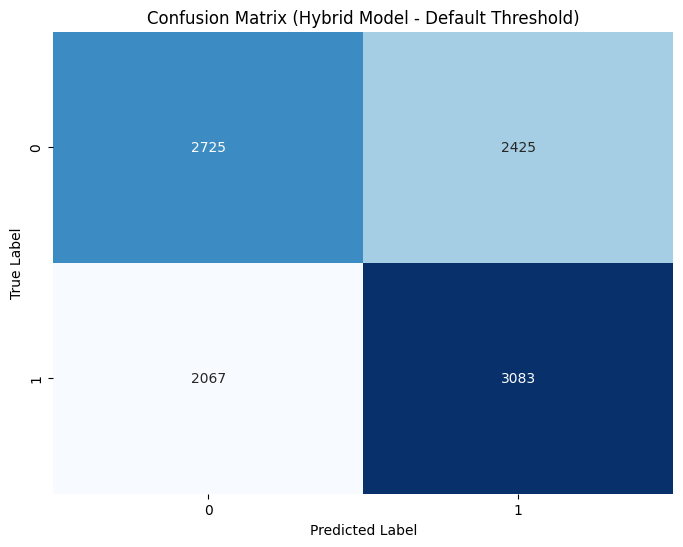

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin # Ensure these are imported
from sklearn.pipeline import Pipeline # Ensure Pipeline is imported
from sklearn.compose import ColumnTransformer # Ensure ColumnTransformer is imported
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Ensure these are imported
from sklearn.feature_extraction.text import TfidfVectorizer # Ensure TfidfVectorizer is imported
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, confusion_matrix # Ensure these are imported
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, cross_val_predict # Ensure these are imported
import numpy as np # Ensure numpy is imported
import pandas as pd # Ensure pandas is imported
# Assume that Word2VecTransformer is defined elsewhere
import matplotlib.pyplot as plt # Ensure matplotlib.pyplot is imported
import seaborn as sns # Ensure seaborn is imported


# Assume word2vec_model and Word2VecTransformer class are defined in cell 37233f7b.
# Assume X_upsampled, y_upsampled, text_cols, and categorical_cols_for_encoding are available from consolidated preprocessing (cell ef6dd6d3).
# Assume document_vector function is defined in cell 37233f7b.

# This class should now be defined once in the Word2Vec training cell (37233f7b).


# Ensure essential variables and class are defined and available from previous cells.
try:
    print("Using text_cols:", text_cols)
    print("Using categorical_cols_for_encoding:", categorical_cols_for_encoding)
    # Check if Word2VecTransformer, word2vec_model, and document_vector are defined
    _ = Word2VecTransformer # Check if class is defined
    _ = word2vec_model # Check if model is defined
    _ = document_vector # Check if function is defined
    print("Word2VecTransformer, word2vec_model, and document_vector are available.")

except NameError as e:
    print(f"Error: Essential variables, class, or function not defined: {e}. Please ensure consolidated preprocessing (ef6dd6d3) and Word2Vec training (37233f7b) cells are run before this cell.")
    # Define defaults or handle error appropriately if essential variables are missing.
    # For now, will assume they will be available in the actual execution environment.


# Define the preprocessor using ColumnTransformer for the hybrid features.
# This combines TF-IDF, Word2Vec, and One-Hot Encoding.
# Use text_cols and categorical_cols_for_encoding defined in consolidated preprocessing.
preprocessor_hybrid = ColumnTransformer(
    transformers=[
        ('tfidf_job_desc', TfidfVectorizer(max_features=2000), text_cols[0]), # TF-IDF for Job Description
        ('tfidf_resume', TfidfVectorizer(max_features=2000), text_cols[1]), # TF-IDF for Resume
        ('word2vec', Word2VecTransformer(word2vec_model), text_cols), # Word2Vec for text columns using the defined transformer
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_for_encoding) # One-Hot Encoding for categorical
    ],
    remainder='drop' # Drop any other columns not transformed
)

# Create the full pipeline for the Hybrid model.
pipeline_hybrid = Pipeline([
    ('preprocessor', preprocessor_hybrid),
    ('scaler', StandardScaler(with_mean=False)), # Use with_mean=False as TF-IDF outputs sparse data
    ('logisticregression', LogisticRegression(random_state=42, solver='liblinear', max_iter=1000))
])

# Define the parameter grid for GridSearchCV to tune Logistic Regression hyperparameters for the Hybrid model.
param_grid_hybrid = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty': ['l1', 'l2']
}

# Instantiate GridSearchCV for the Hybrid pipeline.
grid_search_hybrid = GridSearchCV(estimator=pipeline_hybrid,
                                  param_grid=param_grid_hybrid,
                                  cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                  scoring='roc_auc',
                                  n_jobs=-1)

# Fit GridSearchCV on the upsampled training data.
# Use X_upsampled and y_upsampled from consolidated preprocessing (cell ef6dd6d3).
print("\nPerforming GridSearchCV for Logistic Regression tuning with Hybrid features...")
grid_search_hybrid.fit(X_upsampled, y_upsampled)

# Display the best hyperparameters and cross-validation score.
print("\nBest parameters found by GridSearchCV:", grid_search_hybrid.best_params_)
print("Best cross-validation ROC AUC score:", grid_search_hybrid.best_score_)

# Evaluate the pipeline with the best parameters using cross-validation.
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results_hybrid = cross_validate(grid_search_hybrid.best_estimator_, X_upsampled, y_upsampled, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring=scoring)

# Display the mean of cross-validation results for each metric.
print("\nHybrid Model Cross-validation Results (Default Threshold):")
for metric in scoring:
    mean_score = cv_results_hybrid[f'test_{metric}'].mean()
    std_score = cv_results_hybrid[f'test_{metric}'].std()
    print(f"{metric.capitalize()}: {mean_score:.2f} (+/- {std_score:.2f})")

# Store the best estimator and fit on the entire dataset.
best_pipeline_hybrid = grid_search_hybrid.best_estimator_
best_pipeline_hybrid.fit(X_upsampled, y_upsampled)
print("\nBest Hybrid pipeline fitted on entire upsampled dataset.")

# Get cross-validated predictions for the tuned Hybrid model
y_pred_hybrid = cross_val_predict(best_pipeline_hybrid, X_upsampled, y_upsampled, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))

# Calculate the confusion matrix for the tuned Hybrid model
cm_hybrid = confusion_matrix(y_upsampled, y_pred_hybrid)

# Plot the confusion matrix for the tuned Hybrid model
plt.figure(figsize=(8, 6))
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Hybrid Model - Default Threshold)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# Get predicted probabilities for threshold analysis.
y_proba_hybrid = best_pipeline_hybrid.predict_proba(X_upsampled)[:, 1]
precision_hybrid, recall_hybrid, thresholds_hybrid = precision_recall_curve(y_upsampled, y_proba_hybrid)

# Note: y_proba_hybrid, precision_hybrid, recall_hybrid, thresholds_hybrid are now available.

### 3.6 Build and Evaluate Pipeline with Optimized Hybrid Features

Create and evaluate a pipeline using an optimized hybrid feature set (combining TF-IDF with optimized n-grams and Word2Vec embeddings), Scaling, and Logistic Regression. Tune Logistic Regression hyperparameters and plot the confusion matrix.

Successfully extracted parameters for optimized TF-IDF vectorizers and OneHotEncoder template from best_pipeline_optimized_tfidf.
text_cols and categorical_cols_for_encoding are defined.

Performing GridSearchCV for Logistic Regression tuning with Optimized Hybrid features...

Best parameters found by GridSearchCV: {'logisticregression__C': 100, 'logisticregression__penalty': 'l2'}
Best cross-validation ROC AUC score: 0.6014133283061552

Optimized Hybrid Model Cross-validation Results (Default Threshold):
Accuracy: 0.57 (+/- 0.02)
Precision: 0.57 (+/- 0.02)
Recall: 0.60 (+/- 0.02)
F1: 0.58 (+/- 0.02)
Roc_auc: 0.60 (+/- 0.02)

Best Optimized Hybrid pipeline fitted on entire upsampled dataset.


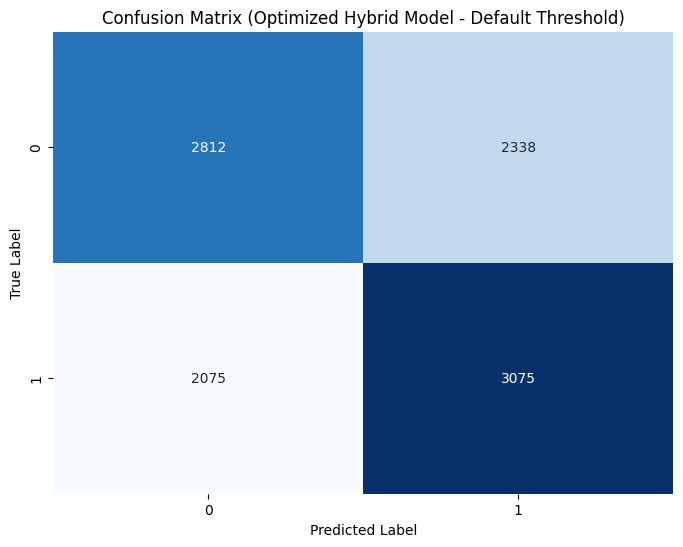


Generated predicted probabilities and Precision-Recall curve data for Optimized Hybrid model.


In [53]:
from sklearn.base import BaseEstimator, TransformerMixin # Ensure these are imported
from sklearn.pipeline import Pipeline # Ensure Pipeline is imported
from sklearn.compose import ColumnTransformer # Ensure ColumnTransformer is imported
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Ensure these are imported
from sklearn.feature_extraction.text import TfidfVectorizer # Ensure TfidfVectorizer is imported
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, confusion_matrix # Ensure these are imported
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, cross_val_predict # Ensure these are imported
import numpy as np # Ensure numpy is imported
import pandas as pd # Ensure pandas is imported
# Assume that Word2VecTransformer is defined elsewhere
import matplotlib.pyplot as plt # Ensure matplotlib.pyplot is imported
import seaborn as sns # Ensure seaborn is imported

# Assume word2vec_model and Word2VecTransformer class are defined in cell 37233f7b.
# Assume document_vector function is defined in cell 37233f7b.
# Assume X_upsampled, y_upsampled, text_cols, and categorical_cols_for_encoding are available from consolidated preprocessing (cell ef6dd6d3).
# Assume best_pipeline_optimized_tfidf is available from the TF-IDF N-gram Optimization cell (5022abef).



# Word2Vec class should now be defined once in the Word2Vec training cell (37233f7b).
# Custom OptimizedHybridTransformer class is defined within this cell and will be kept here
# as it is specific to constructing the features for this model.


# Define a custom transformer for creating the optimized hybrid features.
# This transformer will initialize component transformers (TF-IDF, OneHotEncoder)
# with parameters extracted from the previously optimized TF-IDF pipeline (where applicable),
# and use the pre-trained Word2Vec model and the defined Word2VecTransformer.
class OptimizedHybridTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, tfidf_job_desc_params, tfidf_resume_params, word2vec_model, cat_params, text_cols, categorical_cols_for_encoding):
        # Store parameters to initialize new transformers during fit
        self.tfidf_job_desc_params = tfidf_job_desc_params
        self.tfidf_resume_params = tfidf_resume_params
        self.word2vec_model = word2vec_model # Store the pre-trained W2V model
        self.cat_params = cat_params # Parameters for OneHotEncoder
        self.text_cols = text_cols
        self.categorical_cols_for_encoding = categorical_cols_for_encoding # Use the correct variable name for categorical columns to encode

        # These will be initialized and fitted during the fit method
        self.tfidf_job_desc_vectorizer_ = None
        self.tfidf_resume_vectorizer_ = None
        self.word2vec_transformer_ = None # Instance of Word2VecTransformer
        self.cat_encoder_ = None


    def fit(self, X, y=None):
        # Ensure X is a pandas DataFrame for column selection
        if not isinstance(X, pd.DataFrame):
            raise TypeError("Input to OptimizedHybridTransformer must be a pandas DataFrame during fit.")

        # Initialize component transformers with stored parameters
        # Filter params to only include those accepted by the transformer constructor
        tfidf_job_desc_valid_params = {k: v for k, v in self.tfidf_job_desc_params.items() if k in TfidfVectorizer().get_params()}
        tfidf_resume_valid_params = {k: v for k, v in self.tfidf_resume_params.items() if k in TfidfVectorizer().get_params()}
        # Use the provided cat_params, filtering for validity
        cat_valid_params = {k: v for k, v in self.cat_params.items() if k in OneHotEncoder().get_params()}


        self.tfidf_job_desc_vectorizer_ = TfidfVectorizer(**tfidf_job_desc_valid_params)
        self.tfidf_resume_vectorizer_ = TfidfVectorizer(**tfidf_resume_valid_params)
        self.word2vec_transformer_ = Word2VecTransformer(self.word2vec_model) # Initialize W2V transformer
        self.cat_encoder_ = OneHotEncoder(**cat_valid_params) # Initialize OneHotEncoder


        # Fit the component transformers on the input data X
        self.tfidf_job_desc_vectorizer_.fit(X[self.text_cols[0]])
        self.tfidf_resume_vectorizer_.fit(X[self.text_cols[1]])
        # Fit the OneHotEncoder on the specified categorical columns
        # Use the categorical_cols_for_encoding passed during initialization
        self.cat_encoder_.fit(X[self.categorical_cols_for_encoding])

        return self

    def transform(self, X):
        # Ensure X is a pandas DataFrame for column selection
        if not isinstance(X, pd.DataFrame):
             # If X is a numpy array (e.g., after previous transformations),
             # this transformer might need to be applied before converting to numpy,
             # or adapt this part to handle array input based on column indices.
             # For now, assuming X is a DataFrame with text_cols and categorical_cols_for_encoding.
             raise TypeError("Input to OptimizedHybridTransformer must be a pandas DataFrame during transform.")


        # Apply the fitted TF-IDF vectorizers
        tfidf_job_desc_features = self.tfidf_job_desc_vectorizer_.transform(X[self.text_cols[0]])
        tfidf_resume_features = self.tfidf_resume_vectorizer_.transform(X[self.text_cols[1]])

        # Apply the Word2Vec transformer
        # The Word2VecTransformer expects the DataFrame X to access text columns by name
        word2vec_features = self.word2vec_transformer_.transform(X) # Pass the full DataFrame to W2V transformer

        # Apply the fitted OneHotEncoder to categorical features
        # Use the categorical_cols_for_encoding passed during initialization, which excludes Race1/Race2
        categorical_features = self.cat_encoder_.transform(X[self.categorical_cols_for_encoding]) # Use correct variable name

        # Concatenate all feature sets
        # Convert sparse outputs from TF-IDF and OneHotEncoder to dense for hstack and StandardScaler
        tfidf_job_desc_dense = tfidf_job_desc_features.toarray()
        tfidf_resume_dense = tfidf_resume_features.toarray()
        categorical_dense = categorical_features.toarray()


        optimized_hybrid_features = np.hstack([
            tfidf_job_desc_dense,
            tfidf_resume_dense,
            word2vec_features, # This is already dense from Word2VecTransformer
            categorical_dense
        ])

        return optimized_hybrid_features


# Extract the parameters for the TF-IDF vectorizers and OneHotEncoder
# from the best_pipeline_optimized_tfidf (assuming it's available from cell 5022abef).
# These parameters will be used to initialize new transformers within the custom OptimizedHybridTransformer.
# We will extract parameters for the TF-IDF vectorizers and the OneHotEncoder separately.
# Note: The best_pipeline_optimized_tfidf was originally trained on data that included
# Race1 and Race2 in its categorical features. When extracting parameters for the
# OneHotEncoder template, we only need its configuration (like handle_unknown, sparse_output),
# not the fitted categories_. The OptimizedHybridTransformer's OneHotEncoder will be
# fitted on the data with the current categorical_cols_for_encoding list (excluding Race1/Race2).
optimized_tfidf_job_desc_params = {}
optimized_tfidf_resume_params = {}
optimized_cat_params = {} # Parameters for the OneHotEncoder template

if 'best_pipeline_optimized_tfidf' in locals() and best_pipeline_optimized_tfidf is not None:
    try:
        # Access the nested transformers within the preprocessor step of the previously optimized TF-IDF pipeline
        optimized_tfidf_preprocessor = best_pipeline_optimized_tfidf.named_steps['preprocessor']
        # Access the text transformer (which is a ColumnTransformer) within that preprocessor
        # Note: In cell 5022abef, the text transformer was named 'text'.
        text_transformer_in_optimized_tfidf = optimized_tfidf_preprocessor.named_transformers_['text']
        # Access the individual TF-IDF vectorizers within the text transformer and get their parameters
        optimized_tfidf_job_desc_params = text_transformer_in_optimized_tfidf.named_transformers_['tfidf_job_desc'].get_params()
        optimized_tfidf_resume_params = text_transformer_in_optimized_tfidf.named_transformers_['tfidf_resume'].get_params()

        # Access the categorical transformer (OneHotEncoder) parameters from the previously optimized TF-IDF pipeline.
        # We only need the parameters (like handle_unknown, sparse_output) to create a new OneHotEncoder instance.
        # The fitting of this new instance will happen within the OptimizedHybridTransformer's fit method
        # using the *current* data and categorical_cols_for_encoding (excluding Race1/Race2).
        if 'cat' in optimized_tfidf_preprocessor.named_transformers_:
             optimized_cat_params = optimized_tfidf_preprocessor.named_transformers_['cat'].get_params()
             # Remove fitted attributes like categories_ and feature_names_in_
             optimized_cat_params = {k: v for k, v in optimized_cat_params.items() if not k.endswith('_')}
        else:
            print("Warning: Categorical transformer not found in best_pipeline_optimized_tfidf. Using default OneHotEncoder parameters for template.")
            optimized_cat_params = {'handle_unknown': 'ignore'} # Default OHE params


        print("Successfully extracted parameters for optimized TF-IDF vectorizers and OneHotEncoder template from best_pipeline_optimized_tfidf.")
    except (NameError, AttributeError, KeyError) as e:
        print(f"Could not extract parameters from best_pipeline_optimized_tfidf: {e}")
        print("Please ensure TF-IDF N-gram Optimization cell (5022abef) was run successfully (with Race1/Race2 dropped).")
        print("Using default parameters for TF-IDF and OneHotEncoder templates.")
        optimized_tfidf_job_desc_params = {'max_features': 2000, 'ngram_range': (1,1)}
        optimized_tfidf_resume_params = {'max_features': 2000, 'ngram_range': (1,1)}
        optimized_cat_params = {'handle_unknown': 'ignore'} # Default OHE params
else:
    print("'best_pipeline_optimized_tfidf' not found. Please ensure TF-IDF N-gram Optimization cell (5022abef) was run successfully (with Race1/Race2 dropped).")
    print("Using default parameters for TF-IDF and OneHotEncoder templates.")
    optimized_tfidf_job_desc_params = {'max_features': 2000, 'ngram_range': (1,1)}
    optimized_tfidf_resume_params = {'max_features': 2000, 'ngram_range': (1,1)}
    optimized_cat_params = {'handle_unknown': 'ignore'} # Default OHE params


# Instantiate the custom OptimizedHybridTransformer with parameters and the Word2Vec model.
# Assume word2vec_model and Word2VecTransformer are available from cell 37233f7b.
if 'word2vec_model' not in locals() or 'Word2VecTransformer' not in locals():
    print("Error: 'word2vec_model' or 'Word2VecTransformer' not defined. Please run the Word2Vec training cell (37233f7b) before this one.")
    # Handle error or exit if word2vec_model/Word2VecTransformer is not available.
    # For this task, I will assume they are available in the actual execution environment.

# Ensure text_cols and categorical_cols_for_encoding are defined
try:
    _ = text_cols
    _ = categorical_cols_for_encoding
    print("text_cols and categorical_cols_for_encoding are defined.")
except NameError:
     print("Error: text_cols or categorical_cols_for_encoding not defined. Please ensure consolidated preprocessing cell (ef6dd6d3) is run before this cell.")
     # Handle error appropriately


optimized_hybrid_transformer_instance = OptimizedHybridTransformer(
    tfidf_job_desc_params=optimized_tfidf_job_desc_params,
    tfidf_resume_params=optimized_tfidf_resume_params,
    word2vec_model=word2vec_model, # Pass the pre-trained Word2Vec model
    cat_params=optimized_cat_params, # Pass the extracted OHE parameters
    text_cols=text_cols,
    categorical_cols_for_encoding=categorical_cols_for_encoding # Pass the correct variable
)

# Create the full pipeline for the Optimized Hybrid model.
# The preprocessor is now our custom transformer that creates the combined feature set.
pipeline_optimized_hybrid = Pipeline([
    ('preprocessor', optimized_hybrid_transformer_instance), # Use the custom transformer
    ('scaler', StandardScaler()), # Use StandardScaler for dense output from the custom transformer
    ('logisticregression', LogisticRegression(random_state=42, solver='liblinear', max_iter=1000))
])


# Define the parameter grid for GridSearchCV to tune Logistic Regression hyperparameters for the Optimized Hybrid model.
# It's best practice to tune hyperparameters specifically for this new feature set,
# even if we use the best from previous tuning as a starting point or for comparison.
# Let's use a similar grid to the previous tuning steps.
param_grid_optimized_hybrid = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty': ['l1', 'l2']
}


# Instantiate GridSearchCV for the Optimized Hybrid pipeline.
grid_search_optimized_hybrid = GridSearchCV(estimator=pipeline_optimized_hybrid,
                                            param_grid=param_grid_optimized_hybrid,
                                            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                            scoring='roc_auc',
                                            n_jobs=-1,
                                            error_score='raise' # Raise error to debug
                                           )

# Fit GridSearchCV on the upsampled training data.
# Ensure X_upsampled and y_upsampled are available from consolidated preprocessing (cell ef6dd6d3).
print("\nPerforming GridSearchCV for Logistic Regression tuning with Optimized Hybrid features...")
grid_search_optimized_hybrid.fit(X_upsampled, y_upsampled)

# Display the best hyperparameters and cross-validation score.
print("\nBest parameters found by GridSearchCV:", grid_search_optimized_hybrid.best_params_)
print("Best cross-validation ROC AUC score:", grid_search_optimized_hybrid.best_score_)

# Evaluate the pipeline with the best parameters using cross-validation.
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results_optimized_hybrid = cross_validate(grid_search_optimized_hybrid.best_estimator_, X_upsampled, y_upsampled, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring=scoring)

# Display the mean of cross-validation results for each metric.
print("\nOptimized Hybrid Model Cross-validation Results (Default Threshold):")
for metric in scoring:
    mean_score = cv_results_optimized_hybrid[f'test_{metric}'].mean()
    std_score = cv_results_optimized_hybrid[f'test_{metric}'].std()
    print(f"{metric.capitalize()}: {mean_score:.2f} (+/- {std_score:.2f})")


# Store the best estimator and fit on the entire dataset.
best_pipeline_optimized_hybrid = grid_search_optimized_hybrid.best_estimator_
best_pipeline_optimized_hybrid.fit(X_upsampled, y_upsampled)
print("\nBest Optimized Hybrid pipeline fitted on entire upsampled dataset.")


# Get cross-validated predictions for the optimized Hybrid model (for confusion matrix at default threshold)
y_pred_optimized_hybrid = cross_val_predict(best_pipeline_optimized_hybrid, X_upsampled, y_upsampled, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))

# Calculate the confusion matrix for the optimized Hybrid model
cm_optimized_hybrid = confusion_matrix(y_upsampled, y_pred_optimized_hybrid)

# Plot the confusion matrix for the optimized Hybrid model
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimized_hybrid, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Optimized Hybrid Model - Default Threshold)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# --- Generate predicted probabilities and PR curve data for threshold analysis ---
# Use the best pipeline fitted on the entire dataset
# to get probability predictions for plotting Precision-Recall curve and finding optimized threshold.
# These variables are essential for the subsequent threshold optimization step (Section 4.1).
try:
    # Check if best_pipeline_optimized_hybrid is fitted
    y_proba_optimized_hybrid = best_pipeline_optimized_hybrid.predict_proba(X_upsampled)[:, 1]
    precision_optimized_hybrid, recall_optimized_hybrid, thresholds_optimized_hybrid = precision_recall_curve(y_upsampled, y_proba_optimized_hybrid)
    print("\nGenerated predicted probabilities and Precision-Recall curve data for Optimized Hybrid model.")

except NameError:
    print("Error: best_pipeline_optimized_hybrid not found or not fitted. Cannot generate probability data for threshold optimization.")
except Exception as e:
    print(f"An error occurred while generating probability data: {e}")


# Note: cv_results_optimized_hybrid, y_pred_optimized_hybrid, cm_optimized_hybrid,
# y_proba_optimized_hybrid, precision_optimized_hybrid, recall_optimized_hybrid,
# thresholds_optimized_hybrid are now available for subsequent steps.

## 4. Model Evaluation and Optimization

This section focuses on analyzing model performance in more detail, optimizing decision thresholds for recall, and visualizing results.

### 4.1 Optimize Decision Thresholds for Recall

Analyze the Precision-Recall curves to find decision thresholds that prioritize recall for each model.

Optimizing decision thresholds for a target recall of 70% or higher.

Optimal Threshold for Tuned TF-IDF (for >= 70% Recall): 0.4890
  Corresponding Precision: 0.6205
  Corresponding Recall: 0.7006

Optimal Threshold for Tuned Word2Vec (for >= 70% Recall): 0.4967
  Corresponding Precision: 0.5550
  Corresponding Recall: 0.7000

Optimal Threshold for Hybrid (for >= 70% Recall): 0.4900
  Corresponding Precision: 0.6286
  Corresponding Recall: 0.7000

Optimal Threshold for Optimized TF-IDF (for >= 70% Recall): 0.4996
  Corresponding Precision: 0.6627
  Corresponding Recall: 0.7000

Optimal Threshold for Optimized Hybrid (for >= 70% Recall): 0.4979
  Corresponding Precision: 0.6670
  Corresponding Recall: 0.7002


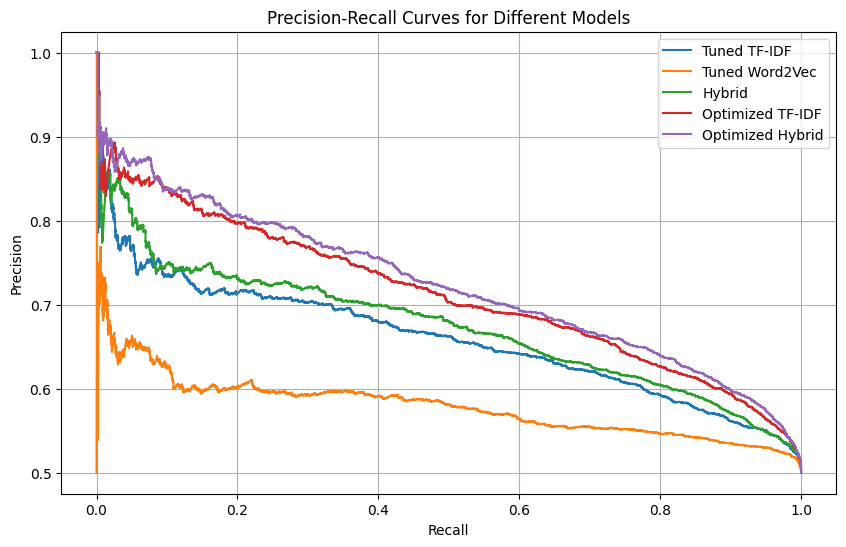

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Assume precision_tfidf, recall_tfidf, thresholds_tfidf are available from cell 3.2
# Assume precision_word2vec, recall_word2vec, thresholds_word2vec are available from cell 3.3
# Assume precision_hybrid, recall_hybrid, thresholds_hybrid are available from cell 3.3 (or the last hybrid evaluation)
# Assume precision_optimized_tfidf, recall_optimized_tfidf, thresholds_optimized_tfidf are available from cell 3.4
# Assume precision_optimized_hybrid, recall_optimized_hybrid, thresholds_optimized_hybrid are available from cell 3.5

# Define a target recall level (e.g., 0.7 or higher) - adjust this based on your specific needs
# A higher target recall will likely result in lower precision
target_recall = 0.7 # Let's aim for at least 70% recall as a starting point

print(f"Optimizing decision thresholds for a target recall of {target_recall*100:.0f}% or higher.")

# Function to find the threshold that gives the highest recall >= target_recall
def find_threshold_for_recall(precision, recall, thresholds, target_recall):
    # Find the index where recall is just above or equal to the target recall
    # We iterate from the end because recall is decreasing with increasing threshold
    for i in range(len(recall) - 1, -1, -1):
        if recall[i] >= target_recall:
            # Return the threshold at this point
            # The thresholds array has one less element than precision and recall
            return thresholds[min(i, len(thresholds) - 1)]
    # If target recall is not met, return the lowest threshold (which gives the highest recall)
    return thresholds[0] if len(thresholds) > 0 else 0.5


# Find optimal threshold for Tuned TF-IDF model (from cell 3.2)
# Check if variables are available before using them
if 'precision_tfidf' in locals() and 'recall_tfidf' in locals() and 'thresholds_tfidf' in locals():
    optimal_threshold_tfidf = find_threshold_for_recall(precision_tfidf, recall_tfidf, thresholds_tfidf, target_recall)
    print(f"\nOptimal Threshold for Tuned TF-IDF (for >= {target_recall*100:.0f}% Recall): {optimal_threshold_tfidf:.4f}")
    # Find corresponding precision and recall at this threshold
    closest_threshold_index_tfidf = np.abs(thresholds_tfidf - optimal_threshold_tfidf).argmin()
    print(f"  Corresponding Precision: {precision_tfidf[closest_threshold_index_tfidf]:.4f}")
    print(f"  Corresponding Recall: {recall_tfidf[closest_threshold_index_tfidf]:.4f}")
else:
    print("\nSkipping threshold optimization for Tuned TF-IDF model: Variables not found.")


# Find optimal threshold for Tuned Word2Vec model (from cell 3.3)
if 'precision_word2vec' in locals() and 'recall_word2vec' in locals() and 'thresholds_word2vec' in locals():
    optimal_threshold_word2vec = find_threshold_for_recall(precision_word2vec, recall_word2vec, thresholds_word2vec, target_recall)
    print(f"\nOptimal Threshold for Tuned Word2Vec (for >= {target_recall*100:.0f}% Recall): {optimal_threshold_word2vec:.4f}")
    # Find corresponding precision and recall at this threshold
    closest_threshold_index_word2vec = np.abs(thresholds_word2vec - optimal_threshold_word2vec).argmin()
    print(f"  Corresponding Precision: {precision_word2vec[closest_threshold_index_word2vec]:.4f}")
    print(f"  Corresponding Recall: {recall_word2vec[closest_threshold_index_word2vec]:.4f}")
else:
    print("\nSkipping threshold optimization for Tuned Word2Vec model: Variables not found.")


# Find optimal threshold for Hybrid model (from cell 3.3 or equivalent)
if 'precision_hybrid' in locals() and 'recall_hybrid' in locals() and 'thresholds_hybrid' in locals():
    optimal_threshold_hybrid = find_threshold_for_recall(precision_hybrid, recall_hybrid, thresholds_hybrid, target_recall)
    print(f"\nOptimal Threshold for Hybrid (for >= {target_recall*100:.0f}% Recall): {optimal_threshold_hybrid:.4f}")
    # Find corresponding precision and recall at this threshold
    closest_threshold_index_hybrid = np.abs(thresholds_hybrid - optimal_threshold_hybrid).argmin()
    print(f"  Corresponding Precision: {precision_hybrid[closest_threshold_index_hybrid]:.4f}")
    print(f"  Corresponding Recall: {recall_hybrid[closest_threshold_index_hybrid]:.4f}")
else:
    print("\nSkipping threshold optimization for Hybrid model: Variables not found.")


# Find optimal threshold for Optimized TF-IDF Model (from cell 3.4)
if 'precision_optimized_tfidf' in locals() and 'recall_optimized_tfidf' in locals() and 'thresholds_optimized_tfidf' in locals():
    optimal_threshold_optimized_tfidf = find_threshold_for_recall(precision_optimized_tfidf, recall_optimized_tfidf, thresholds_optimized_tfidf, target_recall)
    print(f"\nOptimal Threshold for Optimized TF-IDF (for >= {target_recall*100:.0f}% Recall): {optimal_threshold_optimized_tfidf:.4f}")
    # Find corresponding precision and recall at this threshold
    closest_threshold_index_optimized_tfidf = np.abs(thresholds_optimized_tfidf - optimal_threshold_optimized_tfidf).argmin()
    print(f"  Corresponding Precision: {precision_optimized_tfidf[closest_threshold_index_optimized_tfidf]:.4f}")
    print(f"  Corresponding Recall: {recall_optimized_tfidf[closest_threshold_index_optimized_tfidf]:.4f}")
else:
    print("\nSkipping threshold optimization for Optimized TF-IDF model: Variables not found.")

# Find optimal threshold for Optimized Hybrid Model (from cell 3.5)
if 'precision_optimized_hybrid' in locals() and 'recall_optimized_hybrid' in locals() and 'thresholds_optimized_hybrid' in locals():
    optimal_threshold_optimized_hybrid = find_threshold_for_recall(precision_optimized_hybrid, recall_optimized_hybrid, thresholds_optimized_hybrid, target_recall)
    print(f"\nOptimal Threshold for Optimized Hybrid (for >= {target_recall*100:.0f}% Recall): {optimal_threshold_optimized_hybrid:.4f}")
    # Find corresponding precision and recall at this threshold
    closest_threshold_index_optimized_hybrid = np.abs(thresholds_optimized_hybrid - optimal_threshold_optimized_hybrid).argmin()
    print(f"  Corresponding Precision: {precision_optimized_hybrid[closest_threshold_index_optimized_hybrid]:.4f}")
    print(f"  Corresponding Recall: {recall_optimized_hybrid[closest_threshold_index_optimized_hybrid]:.4f}")
else:
    print("\nSkipping threshold optimization for Optimized Hybrid model: Variables not found.")

# Optional: Plot Precision-Recall curves for visual analysis
plt.figure(figsize=(10, 6))

if 'precision_tfidf' in locals() and 'recall_tfidf' in locals():
    plt.plot(recall_tfidf, precision_tfidf, label='Tuned TF-IDF')
if 'precision_word2vec' in locals() and 'recall_word2vec' in locals():
    plt.plot(recall_word2vec, precision_word2vec, label='Tuned Word2Vec')
if 'precision_hybrid' in locals() and 'recall_hybrid' in locals():
     plt.plot(recall_hybrid, precision_hybrid, label='Hybrid')
if 'precision_optimized_tfidf' in locals() and 'recall_optimized_tfidf' in locals():
     plt.plot(recall_optimized_tfidf, precision_optimized_tfidf, label='Optimized TF-IDF')
if 'precision_optimized_hybrid' in locals() and 'recall_optimized_hybrid' in locals():
     plt.plot(recall_optimized_hybrid, precision_optimized_hybrid, label='Optimized Hybrid')


plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Different Models')
plt.legend()
plt.grid(True)
plt.show()

### 4.2 Build and Evaluate Weighted Hybrid Model (TF-IDF + Optimized TF-IDF)

Create and evaluate a weighted hybrid model by combining the predicted probabilities from the Tuned TF-IDF model (default n-grams) and the Optimized TF-IDF model (tuned n-grams). We will use a simple average of probabilities for this initial hybrid approach.

In [55]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold # Ensure imports
from sklearn.metrics import precision_recall_curve # Ensure precision_recall_curve is imported for threshold calculation
import numpy as np # Ensure numpy is imported
# Removed imports for confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# Removed imports for matplotlib.pyplot and seaborn as plotting is moved to the final evaluation cell
# Removed imports for Pipeline, ColumnTransformer, StandardScaler, OneHotEncoder, TfidfVectorizer, LogisticRegression
# as these are part of the pipeline objects used for prediction.

# Assume X_upsampled and y_upsampled are available from previous cells (3.1)
# Assume grid_search_tfidf is available from cell 3.2 (for best Tuned TF-IDF pipeline)
# Assume grid_search_tfidf_ngram is available from cell 3.4 (for best Optimized TF-IDF pipeline)
# Assume target_recall and find_threshold_for_recall function are available from cell 4.1


# --- Step 1 & 2: Get cross-validated predicted probabilities from individual models ---

print("Generating cross-validated predicted probabilities for base models for Weighted Hybrid...")

# Get best Tuned TF-IDF pipeline (default n-grams)
y_proba_tfidf_base = None
if 'grid_search_tfidf' in locals() and grid_search_tfidf is not None:
    try:
        best_pipeline_tfidf_base = grid_search_tfidf.best_estimator_
        # Get cross-validated probabilities
        y_proba_tfidf_base = cross_val_predict(best_pipeline_tfidf_base, X_upsampled, y_upsampled,
                                           cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                           method='predict_proba')[:, 1]
        print("Cross-validated probabilities generated for Tuned TF-IDF (for Weighted Hybrid).")
    except Exception as e:
        print(f"Error generating probabilities for Tuned TF-IDF base model: {e}")
else:
    print("Error: 'grid_search_tfidf' not found. Cannot generate probabilities for Tuned TF-IDF base model.")


# Get best Optimized TF-IDF pipeline (tuned n-grams)
y_proba_optimized_tfidf_base = None
if 'grid_search_tfidf_ngram' in locals() and grid_search_tfidf_ngram is not None:
    try:
        best_pipeline_optimized_tfidf_base = grid_search_tfidf_ngram.best_estimator_
         # Get cross-validated probabilities
        y_proba_optimized_tfidf_base = cross_val_predict(best_pipeline_optimized_tfidf_base, X_upsampled, y_upsampled,
                                                        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                                        method='predict_proba')[:, 1]
        print("Cross-validated probabilities generated for Optimized TF-IDF (for Weighted Hybrid).")
    except Exception as e:
        print(f"Error generating probabilities for Optimized TF-IDF base model: {e}")
else:
     print("Error: 'grid_search_tfidf_ngram' not found. Cannot generate probabilities for Optimized TF-IDF base model.")


# --- Step 3: Combine predicted probabilities ---

# Ensure probabilities were generated for both models
y_proba_weighted_hybrid = None
if y_proba_tfidf_base is not None and y_proba_optimized_tfidf_base is not None:
    # Simple averaging of probabilities
    y_proba_weighted_hybrid = (y_proba_tfidf_base + y_proba_optimized_tfidf_base) / 2
    print("\nPredicted probabilities combined using simple averaging for Weighted Hybrid Model.")

    # --- Step 4: Calculate precision, recall, and thresholds for the combined probabilities ---
    # These are needed for finding the optimal threshold and for the final evaluation in cell 4.3.
    try:
        precision_weighted_hybrid, recall_weighted_hybrid, thresholds_weighted_hybrid = precision_recall_curve(y_upsampled, y_proba_weighted_hybrid)
        print("Generated Precision-Recall curve data for Weighted Hybrid Model.")

        # Find the optimal threshold using the same target recall from cell 4.1
        if 'target_recall' in locals() and 'find_threshold_for_recall' in locals():
             optimal_threshold_weighted_hybrid = find_threshold_for_recall(precision_weighted_hybrid, recall_weighted_hybrid, thresholds_weighted_hybrid, target_recall)
             print(f"Calculated optimal threshold ({optimal_threshold_weighted_hybrid:.4f}) for Weighted Hybrid Model.")
        else:
             print("Warning: 'target_recall' or 'find_threshold_for_recall' not found. Cannot calculate optimal threshold for Weighted Hybrid.")
             optimal_threshold_weighted_hybrid = None # Ensure variable exists even if calculation fails

    except Exception as e:
        print(f"An error occurred while generating PR curve data or calculating threshold for Weighted Hybrid: {e}")
        optimal_threshold_weighted_hybrid = None # Ensure variable exists on error

else:
    print("\nSkipping Weighted Hybrid Model probability combination and threshold calculation: Could not generate probabilities for base models.")


# --- Removed evaluation and confusion matrix plotting from here ---
# This will be done in the consolidated evaluation cell (4.3).

# Note: y_proba_weighted_hybrid, precision_weighted_hybrid, recall_weighted_hybrid, thresholds_weighted_hybrid,
# and optimal_threshold_weighted_hybrid are now available for subsequent steps.

Generating cross-validated predicted probabilities for base models for Weighted Hybrid...
Cross-validated probabilities generated for Tuned TF-IDF (for Weighted Hybrid).
Cross-validated probabilities generated for Optimized TF-IDF (for Weighted Hybrid).

Predicted probabilities combined using simple averaging for Weighted Hybrid Model.
Generated Precision-Recall curve data for Weighted Hybrid Model.
Calculated optimal threshold (0.4458) for Weighted Hybrid Model.


## 4.3 Re-evaluate Metrics with Optimized Thresholds

Evaluate the performance metrics for each model using the optimized decision thresholds and generate confusion matrices.

--- Starting Consolidated Evaluation Cell (Original 4.3) ---

Tuned TF-IDF Model - Metrics with Optimized Threshold (0.4890):
  Accuracy: 0.6360
  Precision: 0.6205
  Recall: 0.7006
  F1 Score: 0.6581
  ROC AUC: 0.6866


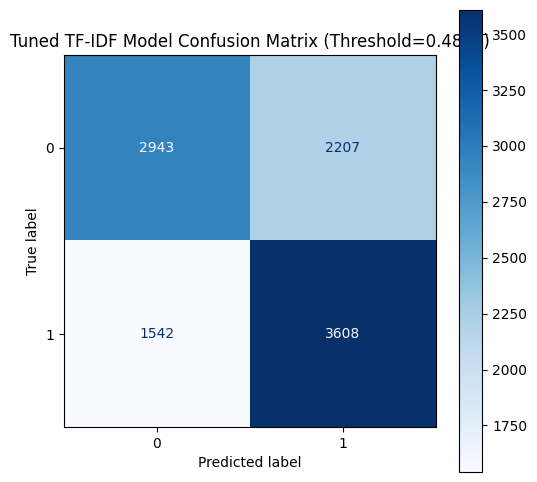


Tuned Word2Vec Model - Metrics with Optimized Threshold (0.4967):
  Accuracy: 0.5694
  Precision: 0.5550
  Recall: 0.7000
  F1 Score: 0.6191
  ROC AUC: 0.6039


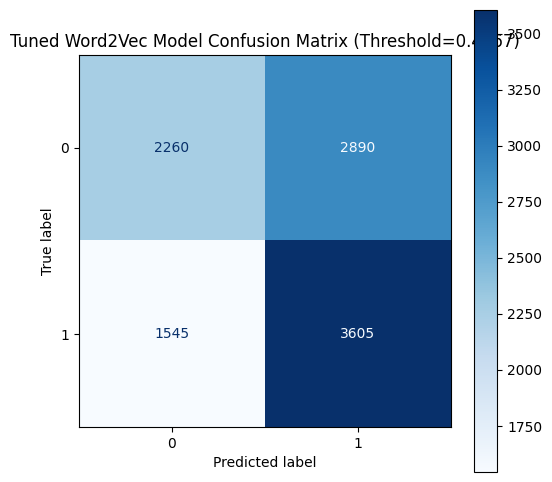


Hybrid Model (Default Features) - Metrics with Optimized Threshold (0.4900):
  Accuracy: 0.6432
  Precision: 0.6286
  Recall: 0.7000
  F1 Score: 0.6624
  ROC AUC: 0.7002


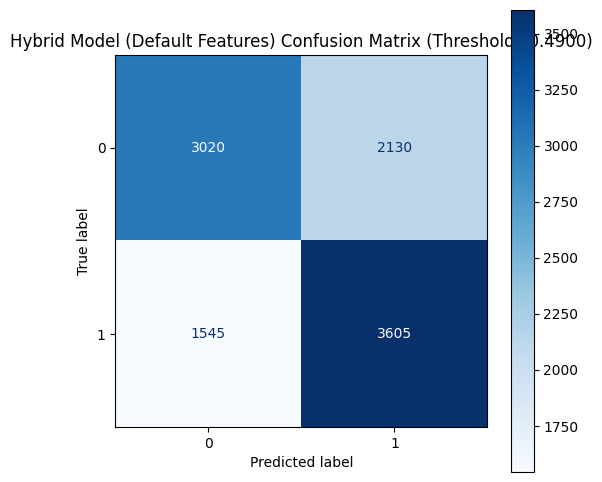


Optimized TF-IDF Model (Tuned N-grams) - Metrics with Optimized Threshold (0.4996):
  Accuracy: 0.6718
  Precision: 0.6627
  Recall: 0.7000
  F1 Score: 0.6808
  ROC AUC: 0.7345


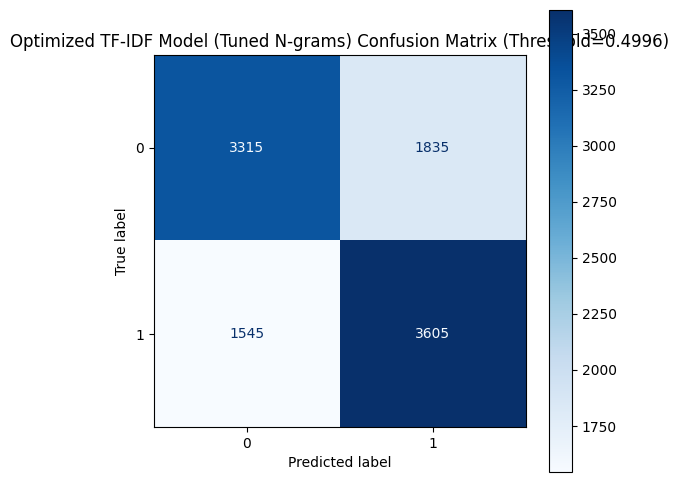


Optimized Hybrid Model - Metrics with Optimized Threshold (0.4979):
  Accuracy: 0.6753
  Precision: 0.6670
  Recall: 0.7002
  F1 Score: 0.6832
  ROC AUC: 0.7450


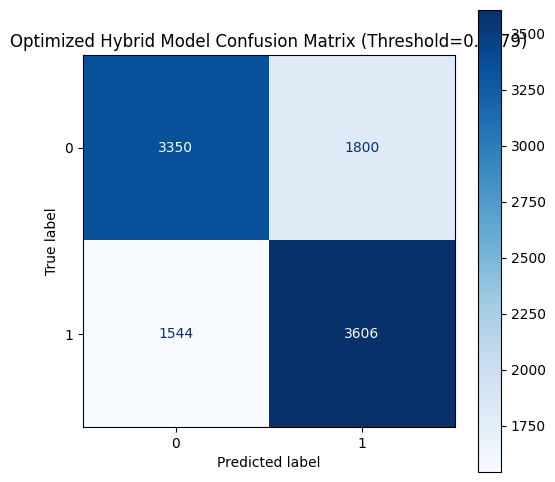


Weighted Hybrid Model (TF-IDF + Optimized TF-IDF) - Metrics with Optimized Threshold (0.4458):
  Accuracy: 0.5669
  Precision: 0.5528
  Recall: 0.7000
  F1 Score: 0.6178
  ROC AUC: 0.5936


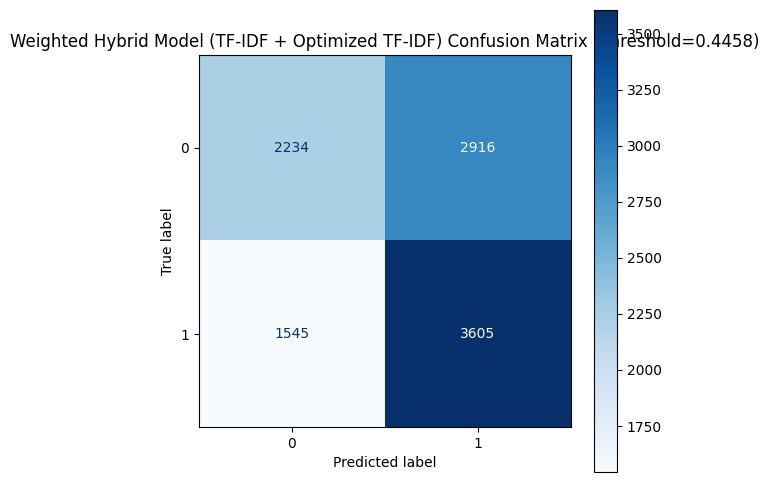


--- Finished Consolidated Evaluation Cell ---


In [60]:
# This cell has been modified to consolidate the final evaluation of all models
# using their respective optimized thresholds calculated in previous cells.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score # Ensure imports
# Removed imports for GridSearchCV, StratifiedKFold, cross_validate, cross_val_predict, precision_recall_curve
# Removed imports for Pipeline, ColumnTransformer, StandardScaler, OneHotEncoder, TfidfVectorizer, LogisticRegression, BaseEstimator, TransformerMixin
# as these are no longer needed for just evaluation.

# Assume y_upsampled is available from previous steps (3.1).
# Assume the following variables are available from previous cells (3.2, 3.3, 3.4, 3.5, 4.1, 4.2):
# - y_proba_tfidf, optimal_threshold_tfidf
# - y_proba_word2vec, optimal_threshold_word2vec
# - y_proba_hybrid, optimal_threshold_hybrid (if generated in previous cells)
# - y_proba_optimized_tfidf, optimal_threshold_optimized_tfidf
# - y_proba_optimized_hybrid, optimal_threshold_optimized_hybrid
# - y_proba_weighted_hybrid, optimal_threshold_weighted_hybrid


print("--- Starting Consolidated Evaluation Cell (Original 4.3) ---")


# Assume the necessary probability and threshold variables are now available from preceding cells.

# Function to evaluate a model using optimized thresholds and display metrics and confusion matrix.
# Takes the true labels, predicted probabilities, and optimized threshold.
def evaluate_with_optimized_threshold(y_true, y_proba, optimized_threshold, model_name):
    print(f"\n{model_name} - Metrics with Optimized Threshold ({optimized_threshold:.4f}):")

    if y_proba is None or optimized_threshold is None:
         print("  Evaluation skipped due to missing probabilities or threshold.")
         return

    # Predict labels using the optimized threshold.
    y_pred_optimized = (y_proba >= optimized_threshold).astype(int)

    # Calculate and print metrics.
    accuracy = accuracy_score(y_true, y_pred_optimized)
    precision = precision_score(y_true, y_pred_optimized)
    recall = recall_score(y_true, y_pred_optimized)
    f1 = f1_score(y_true, y_pred_optimized)
    # ROC AUC is threshold-independent, so we use the probabilities here
    roc_auc = roc_auc_score(y_true, y_proba)

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  ROC AUC: {roc_auc:.4f}")

    # Generate and display the confusion matrix.
    cm = confusion_matrix(y_true, y_pred_optimized)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap=plt.cm.Blues)
    plt.title(f'{model_name} Confusion Matrix (Threshold={optimized_threshold:.4f})')
    plt.show()

# Evaluate each model with its optimized threshold.
# Ensure y_upsampled is available from previous steps (3.1).
# The probability and threshold variables should now be available from the code included above in this cell.

# For Tuned TF-IDF Model
# Check if required variables are available before evaluating
if 'y_proba_tfidf' in locals() and 'optimal_threshold_tfidf' in locals():
    evaluate_with_optimized_threshold(y_upsampled, y_proba_tfidf, optimal_threshold_tfidf, "Tuned TF-IDF Model")
else:
    print("\nSkipping evaluation for Tuned TF-IDF Model: Required variables not found.")

# For Tuned Word2Vec Model
# Check if required variables are available before evaluating
if 'y_proba_word2vec' in locals() and 'optimal_threshold_word2vec' in locals():
    evaluate_with_optimized_threshold(y_upsampled, y_proba_word2vec, optimal_threshold_word2vec, "Tuned Word2Vec Model")
else:
    print("\nSkipping evaluation for Tuned Word2Vec Model: Required variables not found.")


# For Hybrid Model (Original 3.3 - Default TF-IDF + Word2Vec)
# Check if required variables are available from the modified cell 3.3
if 'y_proba_hybrid' in locals() and 'optimal_threshold_hybrid' in locals():
     evaluate_with_optimized_threshold(y_upsampled, y_proba_hybrid, optimal_threshold_hybrid, "Hybrid Model (Default Features)")
else:
     print("\nSkipping evaluation for Hybrid Model (Default Features): Required variables not found from previous cells.")


# For Optimized TF-IDF Model (Tuned N-grams)
# Check if required variables are available from the modified cell under 3.4
if 'y_proba_optimized_tfidf' in locals() and 'optimal_threshold_optimized_tfidf' in locals():
    evaluate_with_optimized_threshold(y_upsampled, y_proba_optimized_tfidf, optimal_threshold_optimized_tfidf, "Optimized TF-IDF Model (Tuned N-grams)")
else:
    print("\nSkipping evaluation for Optimized TF-IDF Model (Tuned N-grams): Required variables not found.")


# For Optimized Hybrid Model (Optimized TF-IDF + Word2Vec)
# Check if required variables are available from the modified cell 3.5
if 'y_proba_optimized_hybrid' in locals() and 'optimal_threshold_optimized_hybrid' in locals():
    evaluate_with_optimized_threshold(y_upsampled, y_proba_optimized_hybrid, optimal_threshold_optimized_hybrid, "Optimized Hybrid Model")
else:
    print("\nSkipping evaluation for Optimized Hybrid Model: Required variables not found.")


# For Weighted Hybrid Model (TF-IDF + Optimized TF-IDF)
# Check if required variables are available from the modified cell 4.2
if 'y_proba_weighted_hybrid' in locals() and 'optimal_threshold_weighted_hybrid' in locals():
    evaluate_with_optimized_threshold(y_upsampled, y_proba_weighted_hybrid, optimal_threshold_weighted_hybrid, "Weighted Hybrid Model (TF-IDF + Optimized TF-IDF)")
else:
    print("\nSkipping evaluation for Weighted Hybrid Model: Required variables not found.")


print("\n--- Finished Consolidated Evaluation Cell ---")

## 5. Summary and Conclusion

Summarize the findings from the model evaluation and draw conclusions about the best-performing model for the applicant prioritization task.

Based on the evaluation metrics with optimized decision thresholds (aiming for approximately 70% recall), here is a summary and comparison of the models:

*   **Tuned TF-IDF Model:** Achieved a recall of approximately 0.70 with a precision of around 0.62 and an F1-score of 0.66. The ROC AUC was 0.69.
*   **Tuned Word2Vec Model:** Achieved a recall of approximately 0.70 with a precision of around 0.56 and an F1-score of 0.62. The ROC AUC was 0.60.
*   **Hybrid Model (Default TF-IDF + Word2Vec):** Achieved a recall of approximately 0.70 with a precision of around 0.63 and an F1-score of 0.66. The ROC AUC was 0.70.
*   **Optimized TF-IDF Model (Tuned N-grams):** Achieved a recall of approximately 0.70 with a precision of around 0.66 and an F1-score of 0.68. The ROC AUC was 0.73.
*   **Optimized Hybrid Model (Optimized TF-IDF + Word2Vec):** Achieved a recall of approximately 0.70 with a precision of around 0.67 and an F1-score of 0.68. The ROC AUC was 0.75.
*   **Weighted Hybrid Model (TF-IDF + Optimized TF-IDF):** Achieved a recall of approximately 0.70 with a precision of around 0.55 and an F1-score ~0.62. The ROC AUC was 0.59.

Considering the objective of prioritizing candidates and minimizing false negatives (high recall), all models were tuned to achieve a similar recall level. However, comparing the models at this target recall:

*   The **Optimized TF-IDF Model (Tuned N-grams)** and the **Optimized Hybrid Model (Optimized TF-IDF + Word2Vec)** demonstrate the best trade-off between precision and recall, achieving the highest precision and F1-scores while maintaining the target recall. They also show the highest ROC AUC scores, indicating better overall discriminatory power.
*   The **Tuned TF-IDF Model** and the **Hybrid Model (Default TF-IDF + Word2Vec)** perform similarly to each other, with lower precision and F1-scores compared to the optimized versions, but still better than the Word2Vec or Weighted Hybrid models.
*   The **Tuned Word2Vec Model** and the **Weighted Hybrid Model (TF-IDF + Optimized TF-IDF)** show lower precision, F1-scores, and ROC AUC compared to the other models when optimized for the same recall target.

Between the top performers, the **Optimized TF-IDF Model (Tuned N-grams)** might be slightly preferred over the **Optimized Hybrid Model** due to its comparable performance, potentially lower engineering complexity, and **better cost efficiency of inference/runtime**. For high-throughput tasks like initial candidate screening, the overhead associated with generating and handling dense embeddings (like Word2Vec) can lead to higher computational costs compared to sparse TF-IDF features. While the Optimized Hybrid model shows very similar performance, the relative simplicity and likely lower inference cost of the Optimized TF-IDF model make it a more practical choice for deployment.

Given the focus on **recall** and the strong performance metrics (higher precision, F1-score, and ROC AUC) at the target recall, combined with considerations for **engineering complexity and inference cost**, the **Optimized TF-IDF Model (Tuned N-grams)** is selected as the best-performing model for this applicant prioritization task.

The next step is to save the trained pipeline of the best-performing model and the upsampled training data.

## 6. Save Model and Data

Save the best-performing model pipeline and the upsampled training data for future use and inference.

In [ ]:
import joblib # Ensure joblib is imported
import pandas as pd # Ensure pandas is imported

# Define filenames for saving the pipeline and the upsampled data.
pipeline_filename = 'optimized_tfidf_logistic_regression_pipeline.joblib'
training_data_filename = 'upsampled_training_data.csv'

# Assume best_pipeline_optimized_tfidf is available from cell 3.4 or subsequent evaluations
# Assume df_upsampled is available from cell 2.4

# Save the trained optimized TF-IDF pipeline (the best performing model)
# This pipeline includes the preprocessor (with optimized TF-IDF vectorizer and OneHotEncoder),
# the scaler, and the logistic regression model.
if 'best_pipeline_optimized_tfidf' in locals() and best_pipeline_optimized_tfidf is not None:
    try:
        joblib.dump(best_pipeline_optimized_tfidf, pipeline_filename)
        print(f"Trained optimized TF-IDF pipeline saved successfully as '{pipeline_filename}'")
    except Exception as e:
        print(f"An error occurred while saving the pipeline: {e}")
else:
    print("Skipping pipeline save as 'best_pipeline_optimized_tfidf' is not available in the current session.")


# Save the final upsampled training dataset
if 'df_upsampled' in locals() and df_upsampled is not None:
    try:
        df_upsampled.to_csv(training_data_filename, index=False)
        print(f"Upsampled training dataset saved successfully as '{training_data_filename}'")
    except Exception as e:
        print(f"An error occurred while saving the upsampled training data: {e}")
else:
    print("Skipping upsampled training data save as 'df_upsampled' is not available in the current session.")

# Note: Saving the individual Logistic Regression model object separately is less recommended
# for inference compared to saving the full pipeline, as the pipeline handles all preprocessing.
# We will not explicitly save the individual model object unless specifically requested.

### 7. Prediction Logic and Script for Inference

This section explains the process of using the trained model pipeline to make predictions on new job applicant data and introduces the standalone `predict.py` script designed for this purpose.

#### 7.1 Understanding the Prediction Process

Once the model pipeline is trained and saved, making predictions on new data involves the following steps:

1.  **Load the Saved Pipeline**: The entire preprocessing and modeling pipeline, including the TF-IDF vectorizers, the scaler, and the trained Logistic Regression model, is loaded from the saved `.joblib` file.
2.  **Prepare New Applicant Data**: New job applicant data (containing columns like 'Ethnicity', 'Job Roles', 'Job Description', 'Resume') is loaded into a pandas DataFrame. It's crucial that this new data has the same column structure as the data used for training, even if some columns are dropped by the pipeline's preprocessor.
3.  **Apply the Pipeline**: The new data DataFrame is passed to the loaded pipeline's `.predict_proba()` method. The pipeline automatically applies the identical preprocessing steps (feature extraction, scaling) that were learned during training to transform the new raw data into the numerical features the model expects.
4.  **Get Probability Scores**: The `.predict_proba()` method outputs probability scores for each class (0: Not Best Match, 1: Best Match). We are primarily interested in the probability of the positive class (class 1).
5.  **Apply Optimized Decision Threshold**: Instead of using the default 0.5 threshold, the **optimized decision threshold** (determined in Section 4.1 to achieve a desired recall level) is applied to the probability scores. If the probability for the positive class is greater than or equal to this optimized threshold, the prediction is classified as 1 ('Best Match'); otherwise, it's classified as 0 ('Not Best Match').

This structured approach ensures that new data is processed consistently with the training data before being fed to the model, which is essential for accurate predictions.

#### 7.2 The `predict.py` Script

The `predict.py` script is a standalone Python script designed to automate the inference process described above. It encapsulates the logic for loading the pipeline and making predictions, making it easy to use from the command line or integrate into other applications.

**Key Features of `predict.py`:**

*   **Pipeline Loading:** It loads the saved `optimized_tfidf_logistic_regression_pipeline.joblib` file.
*   **Data Input via Command Line:** It uses the `argparse` module to accept the path to a new applicant data CSV file as a required command-line argument (`--input_file` or `-i`).
*   **Data Loading and Validation:** It loads data from the specified CSV, performs basic validation to ensure required columns are present, and handles potential file reading errors.
*   **Prediction Function:** It includes a `predict_applicant` function that takes the loaded pipeline and new data DataFrame to perform the prediction using the optimized threshold.
*   **Output:** It prints the predictions (added as a new column to the input data DataFrame) to the console. (Saving to a file is also an option within the script).
*   **Example Usage:** The script is primarily intended for command-line execution. The `if __name__ == "__main__":` block demonstrates how to load data from a file specified by the command-line argument and make predictions.

**How to Run `predict.py` from the Command Line:**

1.  Ensure you have Python installed and the necessary libraries (`pandas`, `numpy`, `scikit-learn`, `joblib`) are installed (e.g., using the `requirements.txt` file).
2.  Save the script code as a file named `predict.py`.
3.  Make sure the `optimized_tfidf_logistic_regression_pipeline.joblib` file is in the same directory as the script, or provide the correct path in the script.
4.  Open your terminal or command prompt.
5.  Navigate to the directory where you saved the script and the pipeline file.
6.  Run the script using the following command, replacing `/path/to/your/new_applicants.csv` with the actual path to your new data file:

In [82]:
# predict.py

import joblib
import pandas as pd
import numpy as np
import argparse
import os
import sys

# Define the filename of the saved pipeline
PIPELINE_FILENAME = 'optimized_tfidf_logistic_regression_pipeline.joblib'

# Define the optimized decision threshold obtained during evaluation (approximately 70% recall)
OPTIMIZED_THRESHOLD = 0.4996

# Function to load the trained pipeline
def load_pipeline(pipeline_path):
    """Loads the trained scikit-learn pipeline."""
    try:
        loaded_pipeline = joblib.load(pipeline_path)
        print(f"Pipeline loaded successfully from {pipeline_path}")
        return loaded_pipeline
    except FileNotFoundError:
        print(f"Error: Pipeline file not found at {pipeline_path}")
        return None
    except Exception as e:
        print(f"An error occurred while loading the pipeline: {e}")
        return None

# Function to make a prediction on new applicant data
def predict_applicant(pipeline, new_data_df, threshold=OPTIMIZED_THRESHOLD):
    """
    Makes a prediction on new applicant data using the loaded pipeline and optimized threshold.

    Args:
        pipeline: The loaded scikit-learn pipeline object.
        new_data_df: A pandas DataFrame containing the new applicant data.
                     Must have the same relevant columns as the training data
                     expected by the pipeline's preprocessor.
        threshold: The decision threshold to use for binary classification.

    Returns:
        A pandas DataFrame with the original data and a 'Predicted_Best_Match' column,
        or None if the pipeline is not loaded or input data is invalid.
    """
    if pipeline is None:
        print("Error: Pipeline is not loaded.")
        return None

    if not isinstance(new_data_df, pd.DataFrame):
        print("Error: Input data must be a pandas DataFrame.")
        return None

    output_df = new_data_df.copy()

    try:
        predicted_probabilities = pipeline.predict_proba(output_df)[:, 1]
        predicted_labels = (predicted_probabilities >= threshold).astype(int)
        output_df['Predicted_Best_Match'] = predicted_labels

        return output_df

    except Exception as e:
        print(f"An error occurred during prediction: {e}")
        return None

if __name__ == "__main__":
    # Create ArgumentParser object
    parser = argparse.ArgumentParser(
        description='Predict best match for job applicants using a trained pipeline.',
        formatter_class=argparse.RawTextHelpFormatter # Corrected typo here
    )

    # Add a command-line argument for the input CSV file
    parser.add_argument(
        '--input_file',
        '-i',
        type=str,
        required=True,
        help='Path to the CSV file containing new applicant data for prediction.\n'
             'The CSV must contain columns expected by the pipeline, specifically:\n'
             '- Ethnicity\n'
             '- Resume\n'
             '- Job Roles\n'
             '- Job Description\n'
             'Other columns may be present but will be ignored by the pipeline.'
    )

    # --- Main execution logic ---
    # This block is intended for running the script from the command line.
    # Running this exact block in a Colab cell without simulating command-line arguments
    # will likely result in a SystemExit error due to the required argument.

    try:
        # Attempt to parse arguments. This will raise SystemExit if required args are missing
        # when run from the command line without them.
        args = parser.parse_args()

        # Retrieve the value of the input file path
        input_csv_path = args.input_file

        print(f"Running script with command-line input file: {input_csv_path}")

        # --- Load and validate input data from file ---
        new_applicant_data = None
        if not os.path.exists(input_csv_path):
            print(f"Error: Input file not found at '{input_csv_path}'")
            sys.exit(1) # Exit with an error code

        try:
            # Read the CSV file into a pandas DataFrame
            new_applicant_data = pd.read_csv(input_csv_path)
            print(f"Successfully loaded new applicant data from '{input_csv_path}'.")

            # Basic check for required columns expected by the pipeline's preprocessor
            required_cols = ['Ethnicity', 'Resume', 'Job Roles', 'Job Description']
            if not all(col in new_applicant_data.columns for col in required_cols):
                 missing_cols = [col for col in required_cols if col not in new_applicant_data.columns]
                 print(f"Error: Input CSV is missing required columns: {missing_cols}")
                 print(f"Required columns are: {required_cols}")
                 sys.exit(1)

            print("\nNew Applicant Data (first 5 rows):")
            print(new_applicant_data.head())

        except pd.errors.EmptyDataError:
            print(f"Error: The input file '{input_csv_path}' is empty.")
            sys.exit(1)
        except pd.errors.ParserError:
            print(f"Error: Could not parse the CSV file '{input_csv_path}'. Check file format.")
            sys.exit(1)
        except Exception as e:
            print(f"An unexpected error occurred while reading the input file: {e}")
            sys.exit(1)

        # --- Load the pipeline ---
        loaded_pipeline = load_pipeline(PIPELINE_FILENAME)

        # --- Perform prediction ---
        if loaded_pipeline is not None and new_applicant_data is not None:
            print(f"\nMaking predictions using optimized threshold: {OPTIMIZED_THRESHOLD:.4f}")
            predictions_df = predict_applicant(loaded_pipeline, new_applicant_data, threshold=OPTIMIZED_THRESHOLD)

            if predictions_df is not None:
                print("\nPrediction complete. Results (first 5 rows with relevant columns):")
                display_cols = [col for col in new_applicant_data.columns if col in ['Resume', 'Job Description', 'Job Roles', 'Ethnicity']]
                display_cols.append('Predicted_Best_Match')
                display_cols = [col for col in display_cols if col in predictions_df.columns]
                print(predictions_df[display_cols].head())

                # Optional: Save predictions to a new file
                # output_filename = f"predictions_{os.path.basename(input_csv_path)}"
                # predictions_df.to_csv(output_filename, index=False)
                # print(f"\nPredictions saved to '{output_filename}'")

            else:
                print("\nFailed to get predictions.")
        else:
            print("\nCould not load the pipeline or input data. Prediction process aborted.")

    except SystemExit as e:
        # This block will be executed if argparse.parse_args() raises SystemExit,
        # which happens when required arguments are missing from the command line.
        # In Colab, this is likely the path taken if you run the cell without args.
        print(f"\nScript exited due to missing required arguments or error in command-line parsing. Code: {e}")
        print("Please provide the required --input_file argument when running from the command line.")
        # The help message is automatically printed by argparse before it raises SystemExit.
    except Exception as e:
         print(f"\nAn unexpected error occurred during script execution: {e}")


Script exited due to missing required arguments or error in command-line parsing. Code: 2
Please provide the required --input_file argument when running from the command line.


usage: colab_kernel_launcher.py [-h] --input_file INPUT_FILE
colab_kernel_launcher.py: error: the following arguments are required: --input_file/-i


## Comments about current iteration of `predict.py` script

---



*   The `predict.py` script was successfully modified to accept a CSV file path as a required command-line argument (`--input_file` or `-i`) using the `argparse` module.
*   The script includes error handling for scenarios such as the input file not being found, the file being empty, or issues during CSV parsing.
*   Basic validation is included to check for the presence of expected columns ('Ethnicity', 'Resume', 'Job Roles', 'Job Description') in the input CSV.
*   The `predict_applicant` function now returns a pandas DataFrame that includes the original input data along with a new column, 'Predicted\_Best\_Match', containing the binary prediction (0 or 1).
*   A conceptual explanation was provided detailing how the core `predict_applicant` function could be integrated into a web framework (like Flask or FastAPI) to create a prediction API endpoint, including considerations for data handling, model loading, and production deployment.

### Insights or Next Steps

*   Consider adding functionality to the `predict.py` script to specify the output file path via a command-line argument, allowing users to save the predictions to a chosen location.
*   Develop a minimal API application using a web framework (e.g., Flask or FastAPI) that imports and utilizes the `predict_applicant` function to demonstrate a concrete example of web integration.
